# 🏥 Projeto Ciência de Dados — MPTI/IFPB 2026.1

**Disciplina:** Ciência de Dados — MPTI/IFPB — 2026.1  
**Docentes:** Damires Souza e Alex Cunha  
**Equipe:** Rodrigo de Queiroz Gonçalves Velez · Caio Jordan de Lima Maia

---

## Contexto

As Doenças Crônicas Não Transmissíveis (DCNT) — cardiovasculares, diabetes, câncer e doenças respiratórias crônicas — são responsáveis por uma parcela significativa da mortalidade no Brasil. A análise desses dados em nível municipal é fundamental para apoiar políticas públicas de saúde, permitindo identificar desigualdades regionais e orientar a distribuição de recursos.

Este projeto integra bases de dados públicas (DataSUS e IBGE) para identificar padrões e perfis municipais de mortalidade por DCNT, aplicando técnicas de ciência de dados: limpeza e integração de dados heterogêneos, análise exploratória, clustering e visualização de resultados.

## Problema de Ciência de Dados

Identificar padrões e perfis de municípios brasileiros em relação à mortalidade por DCNT, a partir da integração de diferentes bases de dados públicas. Especificamente:

- Analisar a distribuição da mortalidade por DCNT em nível municipal
- Identificar agrupamentos de municípios com características semelhantes (clustering)
- Explorar relações entre indicadores de mortalidade e variáveis demográficas

## Fontes de Dados

| Fonte | Descrição | Acesso | Formato bruto |
|-------|-----------|--------|---------------|
| **DataSUS / SIM** | Sistema de Informações sobre Mortalidade — declarações de óbito com causas por CID-10, por município, estado e ano | FTP ftp.datasus.gov.br | DBC |
| **DataSUS / CID-10 v2008** | Tabelas de referência CID-10: capítulos, grupos, categorias, subcategorias e CID-O | HTTP www2.datasus.gov.br | ZIP/CSV |
| **DataSUS / CID-10 FTP** | Tabelas de referência CID-10 em DBF: categorias+subcategorias e capítulos | FTP ftp.datasus.gov.br | DBF |
| **IBGE / POPSVS** | Projeções populacionais por município, disponibilizadas via FTP do DataSUS | FTP ftp.datasus.gov.br | ZIP/DBF |
| **IBGE API REST** | Cadastro oficial de municípios com código IBGE, microrregião, mesorregião e UF | API servicodados.ibge.gov.br | JSON |

Todos os dados são secundários, já agregados e anonimizados pelos órgãos responsáveis — o projeto está em conformidade com a LGPD.

---

## Arquitetura Medallion

Este notebook cobre a **camada Bronze**: coleta e conversão dos dados brutos das fontes originais para CSV, sem qualquer transformação de conteúdo.

```
🥉 Bronze  →  🥈 Prata  →  🥇 Ouro
(coleta)      (limpeza)    (análise)
```

**Período coberto:** 2010–2024 (15 exercícios)


## ⚙️ Célula 0 — Inicialização: dependências, Google Drive e constantes

Instala as dependências Python necessárias (`pyreaddbc`, `dbfread`, `pandas`, `pyarrow`), define `DATA_DIR` como a pasta `dados/` local (relativa ao notebook) e todas as constantes do projeto: caminhos de pasta, endereços FTP/HTTP, lista de anos (2015–2024) e siglas dos 27 estados. Os diretórios da arquitetura Medallion são criados automaticamente se ainda não existirem.


In [1]:
# ── Instalação de dependências ────────────────────────────────────────────────
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                'pyreaddbc', 'dbfread', 'pandas', 'pyarrow',
                'matplotlib', 'seaborn', 'scikit-learn', 'geopandas'], check=True)
from pathlib import Path

# ── Pasta de dados (relativa ao notebook) ────────────────────────────────────
# Em VSCode/Jupyter local aponta para a pasta dados/ no raiz do projeto.
# Em Colab online ajuste para um caminho absoluto, ex.: Path('/content/dados')
DATA_DIR = Path('dados')

# ── Constantes FTP / URL ─────────────────────────────────────────────────────
FTP_HOST           = 'ftp.datasus.gov.br'
FTP_PATH_SIM       = '/dissemin/publicos/SIM/CID10/DORES/'
FTP_PATH_IBGE_POP  = '/dissemin/publicos/IBGE/POPSVS/'
FTP_PATH_CID       = '/dissemin/publicos/SIM/CID10/TABELAS/'
API_IBGE_MUN       = 'https://servicodados.ibge.gov.br/api/v1/localidades/municipios?orderBy=nome'
URL_CID10_V2008    = 'http://www2.datasus.gov.br/cid10/V2008/downloads/CID10CSV.zip'
URL_IBGE_SHAPEFILE = 'https://geoftp.ibge.gov.br/organizacao_do_territorio/malhas_territoriais/malhas_municipais/municipio_2022/Brasil/BR/BR_Municipios_2022.zip'

# ── Diretórios por camada Medallion ──────────────────────────────────────────
BRONZE_DIR     = DATA_DIR / '1-bronze'
PRATA_DIR      = DATA_DIR / '2-prata'
OURO_DIR       = DATA_DIR / '3-ouro'

CID_V2008_BASE = BRONZE_DIR / 'cid_10_datasus_v2008'
CID_FTP_BASE   = BRONZE_DIR / 'cid_10_datasus_ftp'
SIM_BASE       = BRONZE_DIR / 'SIM'
IBGE_MUN_BASE  = BRONZE_DIR / 'ibge_dados_municipios'
IBGE_POP_BASE  = BRONZE_DIR / 'ibge_populacao'

# ── Parâmetros de coleta ──────────────────────────────────────────────────────
ANOS = list(range(2010, 2025))

ESTADOS = [
    'AC', 'AL', 'AM', 'AP', 'BA', 'CE', 'DF', 'ES', 'GO',
    'MA', 'MG', 'MS', 'MT', 'PA', 'PB', 'PE', 'PI', 'PR',
    'RJ', 'RN', 'RO', 'RR', 'RS', 'SC', 'SE', 'SP', 'TO',
]
CID_FTP_TABELAS = ['CID10.DBF', 'CIDCAP10.DBF']

# ── Cria estrutura de pastas (sem efeito se já existir) ───────────────────────
for _p in ['1-bronze', '2-prata', '3-ouro']:
    (DATA_DIR / _p).mkdir(parents=True, exist_ok=True)

print(f'Pasta de dados       : {DATA_DIR.resolve()}')
print(f'Dados → Bronze.......: {BRONZE_DIR}')
print(f'Dados → Prata........: {PRATA_DIR}')
print(f'Dados → Ouro.........: {OURO_DIR}')
print(f'\nAnos configurados    : {ANOS[0]}–{ANOS[-1]}  ({len(ANOS)} exercícios)')
print(f'Estados configurados : {len(ESTADOS)} UFs')
print('\n✅ Inicialização concluída.')


Pasta de dados       : /home/caio/workspace/Caio-Maia/mpti-cd_202601-projeto/dados
Dados → Bronze.......: dados/1-bronze
Dados → Prata........: dados/2-prata
Dados → Ouro.........: dados/3-ouro

Anos configurados    : 2010–2024  (15 exercícios)
Estados configurados : 27 UFs

✅ Inicialização concluída.


## 🔧 Célula 1 — Imports e utilitários compartilhados

Importa todas as bibliotecas usadas no pipeline e define três funções reutilizáveis:

- **`conectar_ftp()`** — Abre conexão FTP anônima com o DataSUS em modo passivo.
- **`dbc_para_parquet(dbc, parquet)`** — Descomprime o DBC para um DBF temporário via `pyreaddbc`, lê com `dbfread`, salva como Parquet e apaga automaticamente o DBC de origem após sucesso.
- **`dbf_para_parquet(dbf, parquet)`** — Converte DBF diretamente para CSV e apaga o DBF de origem após sucesso.
- **`_limpar_dir_vazio(path)`** — Remove diretórios que ficaram vazios após a exclusão dos arquivos intermediários.


In [2]:
# ── Imports e utilitários compartilhados ──────────────────────────────────────
import ftplib, ssl, gzip, io, re, sys, zipfile, tempfile
import json as _json
import shutil
from pathlib import Path
from urllib.request import urlopen
from urllib.error import URLError

import pandas as pd
import pyreaddbc.readdbc as _readdbc
from dbfread import DBF

def conectar_ftp():
    """Abre conexão FTP anônima com o DataSUS em modo passivo."""
    print(f'Conectando ao FTP {FTP_HOST}...')
    ftp = ftplib.FTP(FTP_HOST, timeout=60)
    ftp.login()
    ftp.set_pasv(True)
    print('Conectado.\n')
    return ftp

def _limpar_dir_vazio(path: Path, niveis: int = 2) -> None:
    """Remove diretórios vazios, subindo até `niveis` níveis acima."""
    for _ in range(niveis):
        try:
            if path.exists() and not any(path.iterdir()):
                path.rmdir()
                path = path.parent
            else:
                break
        except OSError:
            break

def dbc_para_parquet(dbc: Path, parquet: Path) -> bool:
    """
    Converte DBC para Parquet via pyreaddbc + dbfread.
    Apaga o DBC de origem após conversão bem-sucedida (ou se Parquet já existia).
    """
    sucesso = False
    tmp_dbf = None
    if parquet.exists():
        print(f'  [SKIP] {parquet.name}')
        sucesso = True
    else:
        parquet.parent.mkdir(parents=True, exist_ok=True)
        try:
            with tempfile.NamedTemporaryFile(suffix='.dbf', delete=False) as tmp:
                tmp_dbf = Path(tmp.name)
            _readdbc.dbc2dbf(str(dbc), str(tmp_dbf))
            df = pd.DataFrame(iter(DBF(str(tmp_dbf), encoding='latin-1')))
            df.to_parquet(parquet, index=False)
            print(f'  [OK]   {parquet.name}  ({br(len(df))} linhas, {len(df.columns)} colunas)')
            sucesso = True
        except Exception as e:
            print(f'  [ERR]  {dbc.name}: {e}')
            parquet.unlink(missing_ok=True)
        finally:
            if tmp_dbf and tmp_dbf.exists():
                tmp_dbf.unlink()

    return sucesso

def dbc_para_csv(dbc: Path, csv: Path) -> bool:
    """
    Converte DBC para Parquet via pyreaddbc + dbfread.
    Apaga o DBC de origem após conversão bem-sucedida (ou se Parquet já existia).
    """
    sucesso = False
    tmp_dbf = None
    if csv.exists():
        print(f'  [SKIP] {csv.name}')
        sucesso = True
    else:
        csv.parent.mkdir(parents=True, exist_ok=True)
        try:
            with tempfile.NamedTemporaryFile(suffix='.dbf', delete=False) as tmp:
                tmp_dbf = Path(tmp.name)
            _readdbc.dbc2dbf(str(dbc), str(tmp_dbf))
            df = pd.DataFrame(iter(DBF(str(tmp_dbf), encoding='latin-1')))
            df.to_csv(csv, index=False)
            print(f'  [OK]   {csv.name}  ({br(len(df))} linhas, {len(df.columns)} colunas)')
            sucesso = True
        except Exception as e:
            print(f'  [ERR]  {dbc.name}: {e}')
            csv.unlink(missing_ok=True)
        finally:
            if tmp_dbf and tmp_dbf.exists():
                tmp_dbf.unlink()

    return sucesso

def dbf_para_csv(dbf: Path, csv: Path) -> bool:
    """
    Converte DBF para CSV via dbfread.
    """
    sucesso = False
    if csv.exists():
        print(f'  [SKIP] {csv.name}')
        sucesso = True
    else:
        csv.parent.mkdir(parents=True, exist_ok=True)
        try:
            df = pd.DataFrame(iter(DBF(str(dbf), encoding='latin-1')))
            df.to_csv(csv, index=False)
            print(f'  [OK]   {csv.name}  ({br(len(df))} linhas, {len(df.columns)} colunas)')
            sucesso = True
        except Exception as e:
            print(f'  [ERR]  {dbf.name}: {e}')
            csv.unlink(missing_ok=True)

    return sucesso


def dbf_para_parquet(dbf_path: Path, parquet_path: Path) -> bool:
    """
    Converte DBF para Parquet via dbfread.
    Apaga o DBF de origem após conversão bem-sucedida (ou se Parquet já existia).
    """
    sucesso = False
    if parquet_path.exists():
        print(f'  [SKIP] {parquet_path.name}')
        sucesso = True
    else:
        parquet_path.parent.mkdir(parents=True, exist_ok=True)
        try:
            df = pd.DataFrame(iter(DBF(str(dbf_path), encoding='latin-1')))
            df.to_parquet(parquet_path, index=False)
            df.to_csv(parquet_path.with_suffix('.csv'), index=False, sep=';', encoding='utf-8-sig')
            print(f'  [OK]   {parquet_path.name}  ({br(len(df))} linhas, {len(df.columns)} colunas)')
            sucesso = True
        except Exception as e:
            print(f'  [ERR]  {dbf_path.name}: {e}')
            parquet_path.unlink(missing_ok=True)

    return sucesso


def br(n, dec=0):
    """Formata número no padrão brasileiro: ponto milhar, vírgula decimal."""
    s = f'{n:,.{dec}f}'
    return s.replace(',', '\x00').replace('.', ',').replace('\x00', '.')

pd.options.display.float_format = lambda x: br(x, 6)

print('\u2705 Utilitários compartilhados carregados.')

✅ Utilitários compartilhados carregados.


## ⚙️ Célula 2 — Configuração do pipeline

Centraliza as opções ajustáveis sem necessidade de editar o código das etapas. A variável `FONTE_CID10` controla qual fonte de CID-10 será usada: `None` para automático (v2008 com fallback para FTP), `'v2008'` ou `'ftp'` para forçar uma fonte específica.

Fonte CID-10:  
  None    → automático: v2008 com fallback para ftp.  
  'v2008' → somente v2008 (mais completo: capítulos, grupos, categorias).  
  'ftp'   → somente ftp  (sem dados de grupos)


In [3]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ⚙️  CONFIGURAÇÃO — edite aqui antes de executar o pipeline  ║
# ╚══════════════════════════════════════════════════════════════╝

# Fonte CID-10:
#   None    → automático: v2008 com fallback para ftp
#   'v2008' → somente v2008 (mais completo: capítulos, grupos, categorias)
#   'ftp'   → somente ftp  (sem dados de grupos)
FONTE_CID10 = None

print('⚙️  Configuração ativa:')
print(f'   Dados   : {DATA_DIR}')
print(f'   Anos    : {ANOS[0]}–{ANOS[-1]}  ({len(ANOS)} exercícios)')
print(f'   Estados : {len(ESTADOS)} UFs  ({", ".join(ESTADOS[:5])}...)')
print(f'   CID-10  : {FONTE_CID10 or "automático (v2008 → ftp)"}')


⚙️  Configuração ativa:
   Dados   : dados
   Anos    : 2010–2024  (15 exercícios)
   Estados : 27 UFs  (AC, AL, AM, AP, BA...)
   CID-10  : automático (v2008 → ftp)


---

## 🥉 BRONZE — Coleta e conversão dos dados brutos

Esta seção realiza o download de todas as fontes de dados e converte os formatos proprietários (DBC, DBF, ZIP) para CSV. Nenhum conteúdo é alterado — apenas o formato de armazenamento. Os arquivos intermediários (DBC, DBF, ZIP) são excluídos automaticamente após a geração de cada CSV para economizar espaço no Drive.

Execute as quatro células abaixo em ordem. Downloads completos (2010–2024, 27 UFs) podem levar 15–30 minutos dependendo da conexão.


### Bronze 1/4 — DataSUS SIM (Declarações de Óbito)

Acessa o FTP `ftp.datasus.gov.br` no diretório `/dissemin/publicos/SIM/CID10/DORES/` e baixa um arquivo DBC por estado por ano, no formato `DO{UF}{ANO}.dbc` (ex.: `DOSP2023.dbc`). Cada DBC é então convertido para CSV e o DBC é excluído. Com 27 estados × 15 anos, são esperados **405 arquivos**.

> **Nota:** arquivos de anos anteriores a 2018 podem não existir para todos os estados — o pipeline registra `[--]` nesses casos sem interromper a execução.


In [ ]:
# ── Bronze 1/4: DATASUS SIM — Declarações de Óbito ──────────────────────────
# Baixa DBC do FTP e converte para Parquet + CSV.
# Fonte: ftp://ftp.datasus.gov.br/dissemin/publicos/SIM/CID10/DORES/
print(f'── Bronze 1/4: DATASUS SIM — Declarações de Óbito ──────────────────────────\n')

def _baixar_dbc(ftp, ftp_path, arquivo, destino):
    if destino.exists():
        print(f'  [SKIP] {arquivo}')
        return True
    
    destino.parent.mkdir(parents=True, exist_ok=True)
    try:
        ftp.cwd(ftp_path)
        
        with open(destino, 'wb') as f:
            ftp.retrbinary(f'RETR {arquivo}', f.write)

        print(f'  [OK]   {arquivo}  ({destino.stat().st_size / 1024:.1f} KB)')
        return True
    except ftplib.error_perm:
        print(f'  [--]   {arquivo} não encontrado')
        return False
    except Exception as e:
        print(f'  [ERR]  {arquivo}: {e}')
        destino.unlink(missing_ok=True)
        return False

def bronze_sim(anos=ANOS, estados=ESTADOS):
    nome_arq = lambda uf, ano: f'DO{uf}{ano}.dbc'
    arquivos = [(nome_arq(uf, ano), ano) for ano in anos for uf in estados]

    print(f'\n{"=" * 60}')
    print(f'Bronze — SIM (Declarações de Óbito)')
    print(f'FTP     : {FTP_PATH_SIM}')
    print(f'Anos    : {anos[0]}–{anos[-1]}  ({len(anos)} exercícios)')
    print(f'Estados : {len(estados)} UFs')
    print(f'Arquivos: {len(arquivos)} previstos')
    print(f'{"=" * 60}\n')

    print('[ Etapa 1/3 — Download DBC ]\n')
    # Verifica quais arquivos realmente precisam ser baixados (sem parquet nem dbc local)
    pendentes = [
        (nome, ano) for nome, ano in arquivos
        if not (SIM_BASE / 'dbc' / str(ano) / nome).exists()
    ]

    if not pendentes:
        print(f'  [SKIP] Todos os {len(arquivos)} dbc já existem — FTP dispensado.\n')
    else:
        print(f'  {len(pendentes)} arquivo(s) pendente(s) de download.\n')
        ftp = conectar_ftp()
        for nome, ano in pendentes:
            destino = SIM_BASE / 'dbc' / str(ano) / nome
            _baixar_dbc(ftp, FTP_PATH_SIM, nome, destino)
        try:
            ftp.quit()
        except OSError:
            ftp.close()
        print()

    print('[ Etapa 2/3 — Conversão DBC → Parquet ]\n')
    convertidos_parquet = 0
    for nome, ano in arquivos:
        dbc     = SIM_BASE / 'dbc'     / str(ano) / nome
        parquet = SIM_BASE / 'parquet' / str(ano) / nome.replace('.dbc', '.parquet')

        if not dbc.exists():
            continue
        
        if dbc_para_parquet(dbc, parquet):
            convertidos_parquet += 1

    print('[ Etapa 3/3 — Conversão DBC → CSV ]\n')
    convertidos_csv = 0
    for nome, ano in arquivos:
        dbc = SIM_BASE / 'dbc' / str(ano) / nome
        csv = SIM_BASE / 'csv' / str(ano) / nome.replace('.dbc', '.csv')

        if not dbc.exists():
            continue
        
        if dbc_para_csv(dbc, csv):
            convertidos_csv += 1

    print(f'\nConversão concluída (parquet): {convertidos_parquet} arquivo(s).')
    print(f'Parquets em: {SIM_BASE / "parquet"}/\n\n')

    print(f'\nConversão concluída (csv): {convertidos_csv} arquivo(s).')
    print(f'CSVs em: {SIM_BASE / "csv"}/\n')

bronze_sim(ANOS, ESTADOS)

### Bronze 2/4 — IBGE Municípios (API REST)

Consulta a API REST do IBGE (`servicodados.ibge.gov.br`) para obter o cadastro completo de municípios brasileiros com hierarquia geográfica (microrregião, mesorregião, UF e grande região). O resultado é salvo em JSON (formato original) e em CSV (achatado via `json_normalize`). A busca recupera todos os 5 570 municípios independentemente do filtro de estados.


In [ ]:
# ── Bronze 2/4: IBGE Municípios ──────────────────────────────────────────────
# Coleta dados de municípios via API REST do IBGE.
# Sempre busca todos os municípios (referência completa).
# JSON intermediário é preservado no disco.
print(f'── Bronze 2/4: IBGE Municípios ──────────────────────────\n')

def _sigla_uf(m):
    try:
        return m['microrregiao']['mesorregiao']['UF']['sigla']
    except (TypeError, KeyError):
        pass
    try:
        return m['regiao-imediata']['regiao-intermediaria']['UF']['sigla']
    except (TypeError, KeyError):
        return None

def _renomear_colunas(colunas):
    vistas, mapa = set(), {}
    for col in colunas:
        partes = col.split('.')
        novo = (f'{partes[-2]}_{partes[-1]}' if len(partes) > 1 else partes[-1])
        novo = novo.lower().replace('-', '_')
        if novo not in vistas:
            vistas.add(novo)
            mapa[col] = novo
    return mapa

def bronze_municipios(estados_filtro=None):
    ctx = ssl._create_unverified_context()
    sufixo      = ('_' + '_'.join(sorted(estados_filtro))) if estados_filtro else ''
    json_path    = IBGE_MUN_BASE / 'json'    / f'municipios{sufixo}.json'
    parquet_path = IBGE_MUN_BASE / 'parquet' / f'municipios{sufixo}.parquet'

    print(f'\n{"=" * 60}')
    print(f'Bronze — IBGE Municípios')
    print(f'API     : {API_IBGE_MUN}')
    print(f'Filtro  : {(", ".join(estados_filtro) if estados_filtro else "todos os municípios")}')
    print(f'{"=" * 60}\n')

    print('[ Etapa 1/2 — Coleta via API ]\n')
    if parquet_path.exists():
        print(f'  [SKIP] {parquet_path.name} já existe')
    else:
        try:
            with urlopen(API_IBGE_MUN, timeout=60, context=ctx) as resp:
                raw = resp.read()
                if resp.info().get('Content-Encoding') == 'gzip' or raw[:2] == b'\x1f\x8b':
                    raw = gzip.decompress(raw)
                dados = _json.loads(raw.decode('utf-8'))
        except URLError as e:
            print(f'  [ERR]  Falha na requisição: {e}')
            return
        print(f'  [OK]   {br(len(dados))} municípios recebidos')
        if estados_filtro:
            dados = [m for m in dados if _sigla_uf(m) in estados_filtro]
            print(f'  [OK]   {br(len(dados))} municípios após filtro')

        print('\n[ Etapa 2/2 — Gravação e limpeza ]\n')
        json_path.parent.mkdir(parents=True, exist_ok=True)
        with open(json_path, 'w', encoding='utf-8') as f:
            _json.dump(dados, f, ensure_ascii=False, indent=2)
        print(f'  [OK]   {json_path.name}  ({json_path.stat().st_size / 1024:.1f} KB)')

        parquet_path.parent.mkdir(parents=True, exist_ok=True)
        df = pd.json_normalize(dados, sep='.')

        _fallback = {
            'microrregiao.mesorregiao.UF.id':          'regiao-imediata.regiao-intermediaria.UF.id',
            'microrregiao.mesorregiao.UF.sigla':        'regiao-imediata.regiao-intermediaria.UF.sigla',
            'microrregiao.mesorregiao.UF.nome':         'regiao-imediata.regiao-intermediaria.UF.nome',
            'microrregiao.mesorregiao.UF.regiao.id':    'regiao-imediata.regiao-intermediaria.UF.regiao.id',
            'microrregiao.mesorregiao.UF.regiao.sigla': 'regiao-imediata.regiao-intermediaria.UF.regiao.sigla',
            'microrregiao.mesorregiao.UF.regiao.nome':  'regiao-imediata.regiao-intermediaria.UF.regiao.nome',
        }
        for dest, src in _fallback.items():
            if dest in df.columns and src in df.columns:
                df[dest] = df[dest].fillna(df[src])

        mapa = _renomear_colunas(list(df.columns))
        df = df[list(mapa.keys())].rename(columns=mapa).dropna(axis=1, how='all')
        for col in df.select_dtypes(include='float64').columns:
            df[col] = df[col].astype('Int64')
        df.to_parquet(parquet_path, index=False)
        df.to_csv(parquet_path.with_suffix('.csv'), index=False, sep=';', encoding='utf-8-sig')
        print(f'  [OK]   {parquet_path.name}  ({br(len(df))} linhas, {len(df.columns)} colunas)')

    print(f'\nConcluído. Parquet em {parquet_path}\n')

bronze_municipios(estados_filtro=None)

### Bronze 3/4 — IBGE Projeções Populacionais

Baixa do FTP do DataSUS os arquivos `POPSBR{AA}.zip` (um por ano), extrai o DBF contido em cada ZIP e converte para CSV. Após a geração de cada CSV, o ZIP e o DBF correspondentes são excluídos para liberar espaço. Com 15 anos de dados (2010–2024), são esperados **15 CSVs** com população projetada por município, ano e sexo.


In [ ]:
# ── Bronze 3/4: IBGE Projeções Populacionais ─────────────────────────────────
# Baixa ZIP do FTP, extrai DBF, converte para Parquet.
# Arquivos ZIP e DBF são preservados no disco.
# Fonte: ftp://ftp.datasus.gov.br/dissemin/publicos/IBGE/POPSVS/
print(f'── Bronze 3/4: IBGE Projeções Populacionais ──────────────────────────\n')

def _nome_zip_pop(ano):     return f'POPSBR{str(ano)[2:]}.zip'
def _nome_dbf_pop(ano):     return f'POP{str(ano)[2:]}.dbf'
def _nome_csv_pop(ano):     return f'POP{str(ano)[2:]}.csv'
def _nome_parquet_pop(ano): return f'POP{str(ano)[2:]}.parquet'

def _baixar_zip_pop(ftp, arquivo, destino):
    if destino.exists():
        print(f'  [SKIP] {arquivo} (ZIP já existe)')
        return True
    destino.parent.mkdir(parents=True, exist_ok=True)
    try:
        ftp.cwd(FTP_PATH_IBGE_POP)
        with open(destino, 'wb') as f:
            ftp.retrbinary(f'RETR {arquivo}', f.write)
        print(f'  [OK]   {arquivo}  ({destino.stat().st_size / 1024:.1f} KB)')
        return True
    except ftplib.error_perm:
        print(f'  [--]   {arquivo} não encontrado no FTP')
        return False
    except Exception as e:
        print(f'  [ERR]  {arquivo}: {e}')
        destino.unlink(missing_ok=True)
        return False

def _extrair_dbf_pop(zip_path, dbf_dest):
    if dbf_dest.exists():
        print(f'  [SKIP] {dbf_dest.name} (DBF já extraído)')
        return True
    dbf_dest.parent.mkdir(parents=True, exist_ok=True)
    try:
        with zipfile.ZipFile(zip_path, 'r') as z:
            dbfs = [n for n in z.namelist() if n.lower().endswith('.dbf')]
            if not dbfs:
                print(f'  [ERR]  {zip_path.name}: nenhum DBF no ZIP')
                return False
            with z.open(dbfs[0]) as src, open(dbf_dest, 'wb') as dst:
                dst.write(src.read())
        print(f'  [OK]   {dbf_dest.name}  ({dbf_dest.stat().st_size / 1024 / 1024:.1f} MB)')
        return True
    except Exception as e:
        print(f'  [ERR]  {zip_path.name}: {e}')
        dbf_dest.unlink(missing_ok=True)
        return False

def bronze_populacao(anos=ANOS):
    print(f'\n{"=" * 60}')
    print(f'Bronze — IBGE Projeções Populacionais')
    print(f'FTP     : {FTP_PATH_IBGE_POP}')
    print(f'Anos    : {anos[0]}–{anos[-1]}  ({len(anos)} exercícios)')
    print(f'{"=" * 60}\n')

    print('[ Etapa 1/4 — Download ZIP ]\n')
    # Só abre FTP se houver anos sem parquet nem zip local
    pendentes_ftp = [
        ano for ano in anos
        if not (IBGE_POP_BASE / 'parquet' / str(ano) / _nome_parquet_pop(ano)).exists()
        and not (IBGE_POP_BASE / 'zip' / str(ano) / _nome_zip_pop(ano)).exists()
    ]

    if not pendentes_ftp:
        print(f'  [SKIP] Todos os {len(anos)} Parquets já existem — FTP dispensado.\n')
    else:
        print(f'  {len(pendentes_ftp)} ano(s) pendente(s) de download.\n')
        ftp = conectar_ftp()
        for ano in pendentes_ftp:
            zip_dest = IBGE_POP_BASE / 'zip' / str(ano) / _nome_zip_pop(ano)
            _baixar_zip_pop(ftp, _nome_zip_pop(ano), zip_dest)
        try:
            ftp.quit()
        except OSError:
            ftp.close()
    print()

    print('[ Etapa 2/4 — Extração ZIP → DBF ]\n')
    for ano in anos:
        zip_path     = IBGE_POP_BASE / 'zip'     / str(ano) / _nome_zip_pop(ano)
        dbf_dest     = IBGE_POP_BASE / 'dbf'     / str(ano) / _nome_dbf_pop(ano)
        parquet_dest = IBGE_POP_BASE / 'parquet' / str(ano) / _nome_parquet_pop(ano)
        if parquet_dest.exists():
            print(f'  [SKIP] {_nome_dbf_pop(ano)} (Parquet já existe)')
            continue
        if zip_path.exists():
            _extrair_dbf_pop(zip_path, dbf_dest)
    print()

    print('[ Etapa 3/4 — Conversão DBF → Parquet ]\n')
    convertidos_parquet = 0
    for ano in anos:
        dbf_path     = IBGE_POP_BASE / 'dbf'     / str(ano) / _nome_dbf_pop(ano)
        parquet_path = IBGE_POP_BASE / 'parquet' / str(ano) / _nome_parquet_pop(ano)
        
        if not dbf_path.exists() and not parquet_path.exists():
            continue
        
        if dbf_para_parquet(dbf_path, parquet_path):
            convertidos_parquet += 1

    print('[ Etapa 4/4 — Conversão DBF → CSV ]\n')
    convertidos_csv = 0
    for ano in anos:
        dbf_path = IBGE_POP_BASE / 'dbf' / str(ano) / _nome_dbf_pop(ano)
        csv_path = IBGE_POP_BASE / 'csv' / str(ano) / _nome_csv_pop(ano)
        
        if not dbf_path.exists() and not csv_path.exists():
            continue
        
        if dbf_para_csv(dbf_path, csv_path):
            convertidos_csv += 1

    print(f'\nConcluído: {convertidos_parquet} arquivo(s) convertido(s).')
    print(f'Parquets em: {IBGE_POP_BASE / "parquet"}/\n')
    print(f'CSV em: {IBGE_POP_BASE / "csv"}/\n')

bronze_populacao(ANOS)


### Bronze 4/4 — CID-10 (tabelas de referência)

Baixa as tabelas de referência CID-10 de duas fontes complementares:

- **v2008 (HTTP):** arquivo `CID10CSV.zip` do site DataSUS, contendo 6 CSVs com a hierarquia completa — capítulos, grupos, categorias, subcategorias e CID-O. O ZIP é excluído após extração.
- **FTP DataSUS:** arquivos `CID10.DBF` (categorias + subcategorias) e `CIDCAP10.DBF` (capítulos). Os DBFs são excluídos após conversão para CSV.

A variável `FONTE_CID10` (definida na célula de configuração) determina qual fonte será usada. O padrão é usar ambas, v2008 com fallback para FTP.


In [ ]:
# ── Bronze 4/4: CID-10 ───────────────────────────────────────────────────────
# Baixa tabelas de referência CID-10 (fontes v2008 e/ou ftp).
# Arquivos intermediários (ZIP, DBF) são preservados no disco.
print(f'── Bronze 4/4: CID-10 ──────────────────────────\n')

def _limpar_cid(base, nome):
    print(f'  [AVISO] Falha no processamento de "{nome}": {base}')

def _baixar_zip_v2008(destino):
    if destino.exists():
        print(f'  [SKIP] {destino.name}')
        return True
    destino.parent.mkdir(parents=True, exist_ok=True)
    ctx = ssl._create_unverified_context()
    try:
        print(f'  Baixando {URL_CID10_V2008} ...')
        with urlopen(URL_CID10_V2008, timeout=30, context=ctx) as resp:
            destino.write_bytes(resp.read())
        print(f'  [OK]   {destino.name}  ({destino.stat().st_size / 1024:.1f} KB)')
        return True
    except Exception as e:
        print(f'  [ERR]  Download falhou: {e}')
        destino.unlink(missing_ok=True)
        return False

def _extrair_parquets_v2008(zip_path, parquet_dir):
    """Lê cada CSV do ZIP (latin-1, sep=;) e salva como Parquet."""
    parquet_dir.mkdir(parents=True, exist_ok=True)
    convertidos = 0
    with zipfile.ZipFile(zip_path, 'r') as z:
        membros = [n for n in z.namelist() if n.upper().endswith('.CSV')]
        for membro in membros:
            nome_base = Path(membro).name.upper().replace('.CSV', '')
            destino = parquet_dir / f'{nome_base}.parquet'
            if destino.exists():
                print(f'  [SKIP] {destino.name}')
                convertidos += 1
                continue
            try:
                raw = z.read(membro).decode('latin-1')
                df = pd.read_csv(io.StringIO(raw), sep=';', dtype=str)
                df = df.loc[:, ~df.columns.str.match(r'^Unnamed')]
                df.to_parquet(destino, index=False)
                df.to_csv(destino.with_suffix('.csv'), index=False, sep=';', encoding='utf-8-sig')
                print(f'  [OK]   {destino.name}  ({br(len(df))} linhas)')
                convertidos += 1
            except Exception as e:
                print(f'  [ERR]  {destino.name}: {e}')
    return convertidos

def bronze_cid10_v2008():
    print(f'\n{"=" * 60}')
    print(f'Bronze — CID-10 (fonte: v2008)')
    print(f'URL     : {URL_CID10_V2008}')
    print(f'{"=" * 60}\n')
    zip_path    = CID_V2008_BASE / 'zip'     / 'CID10CSV.zip'
    parquet_dir = CID_V2008_BASE / 'parquet'

    print('[ Download ZIP ]\n')
    parquets_existentes = list(parquet_dir.glob('*.parquet')) if parquet_dir.exists() else []
    if len(parquets_existentes) >= 6:
        print(f'  [SKIP] {len(parquets_existentes)} Parquets já existem em {parquet_dir}')
    else:
        if not _baixar_zip_v2008(zip_path):
            _limpar_cid(CID_V2008_BASE, 'v2008')
            return
    print()
    print('[ Extração ZIP → Parquet + CSV ]\n')
    if not zip_path.exists() and not (parquet_dir.exists() and any(parquet_dir.glob('*.parquet'))):
        print(f'  [--] ZIP não encontrado e Parquets ausentes.')
        _limpar_cid(CID_V2008_BASE, 'v2008')
        return

    if zip_path.exists():
        try:
            n = _extrair_parquets_v2008(zip_path, parquet_dir)
        except Exception as e:
            print(f'  [ERR]  {e}')
            _limpar_cid(CID_V2008_BASE, 'v2008')
            return
        if n == 0:
            _limpar_cid(CID_V2008_BASE, 'v2008')
            return
    else:
        n = len(list(parquet_dir.glob('*.parquet')))
        print(f'  [SKIP] {n} Parquets já presentes.')

    print(f'\nConcluído: Parquets em: {parquet_dir}/\n')

def _baixar_ftp_cid(ftp, arquivo, destino):
    if destino.exists():
        print(f'  [SKIP] {arquivo}')
        return True
    destino.parent.mkdir(parents=True, exist_ok=True)
    try:
        ftp.cwd(FTP_PATH_CID)
        with open(destino, 'wb') as f:
            ftp.retrbinary(f'RETR {arquivo}', f.write)
        print(f'  [OK]   {arquivo}  ({destino.stat().st_size / 1024:.1f} KB)')
        return True
    except ftplib.error_perm:
        print(f'  [--]   {arquivo} não encontrado no FTP')
        return False
    except Exception as e:
        print(f'  [ERR]  {arquivo}: {e}')
        destino.unlink(missing_ok=True)
        return False

def bronze_cid10_ftp():
    print(f'\n{"=" * 60}')
    print(f'Bronze — CID-10 (fonte: ftp)')
    print(f'FTP     : ftp://{FTP_HOST}{FTP_PATH_CID}')
    print(f'{"=" * 60}\n')
    print('[ Download DBF ]\n')

    # Só conecta ao FTP se houver tabelas sem parquet nem dbf local
    pendentes_ftp = [
        arq for arq in CID_FTP_TABELAS
        if not (CID_FTP_BASE / 'parquet' / arq.replace('.DBF', '.parquet')).exists()
        and not (CID_FTP_BASE / 'dbf' / arq).exists()
    ]

    if not pendentes_ftp:
        print(f'  [SKIP] Todos os Parquets já existem — FTP dispensado.\n')
    else:
        try:
            ftp = conectar_ftp()
            falhas = sum(
                0 if _baixar_ftp_cid(ftp, arq, CID_FTP_BASE / 'dbf' / arq) else 1
                for arq in pendentes_ftp
            )
            ftp.quit()
        except Exception as e:
            print(f'  [ERR]  FTP: {e}')
            _limpar_cid(CID_FTP_BASE, 'ftp')
            return
        if falhas > 0:
            _limpar_cid(CID_FTP_BASE, 'ftp')
            return

    print()
    print('[ Conversão DBF → Parquet  (DBF excluído após conversão) ]\n')
    convertidos = 0
    for arquivo in CID_FTP_TABELAS:
        dbf_path     = CID_FTP_BASE / 'dbf'     / arquivo
        parquet_path = CID_FTP_BASE / 'parquet' / arquivo.replace('.DBF', '.parquet')
        if not dbf_path.exists() and not parquet_path.exists():
            continue
        if dbf_para_parquet(dbf_path, parquet_path):
            convertidos += 1

    if convertidos == 0:
        _limpar_cid(CID_FTP_BASE, 'ftp')
    else:
        print(f'\nConcluído: {convertidos} tabela(s). Parquets em: {CID_FTP_BASE / "parquet"}/\n')


def bronze_cid10(fonte=FONTE_CID10):
    fontes = [fonte] if fonte else ['v2008', 'ftp']
    for f in fontes:
        if f == 'v2008':
            bronze_cid10_v2008()
        elif f == 'ftp':
            bronze_cid10_ftp()

bronze_cid10(FONTE_CID10)


---

## ✅ Bronze — Resumo dos artefatos gerados

Após a execução bem-sucedida das quatro células acima, a estrutura de pastas conterá apenas Parquets:

```
dados/1-bronze/
├── SIM/
│   └── parquet/
│       ├── 2010/  DO{UF}2010.parquet  (até 27 arquivos)
│       ├── ...
│       └── 2024/  DO{UF}2024.parquet
├── ibge_dados_municipios/
│   └── parquet/
│       └── municipios.parquet
├── ibge_populacao/
│   └── parquet/
│       ├── 2010/  POP10.parquet
│       ├── ...
│       └── 2024/  POP24.parquet
├── cid_10_datasus_v2008/
│   └── parquet/
│       ├── CID-10-CAPITULOS.parquet
│       ├── CID-10-GRUPOS.parquet
│       ├── CID-10-CATEGORIAS.parquet
│       ├── CID-10-SUBCATEGORIAS.parquet
│       ├── CID-O-CATEGORIAS.parquet
│       └── CID-O-GRUPOS.parquet
└── cid_10_datasus_ftp/
    └── parquet/
        ├── CID10.parquet
        └── CIDCAP10.parquet
```

Os arquivos intermediários (`.dbc`, `.dbf`, `.zip`, `.json`) são excluídos automaticamente junto com suas pastas após a geração de cada Parquet.

> **Próximo passo:** executar o notebook da **camada Prata** para limpeza, normalização e integração dos dados.


---

## 🥈 PRATA — Limpeza, normalização e integração

Lê os Parquets da camada Bronze, normaliza e produz datasets prontos para análise.  
Nenhum dado é baixado nesta etapa — apenas transformação de conteúdo.

Execute as quatro células abaixo em ordem, ou use a célula **Prata — Execução principal** para rodar tudo de uma vez.

In [ ]:
# ── Prata 1/4: CID-10 ────────────────────────────────────────────────────────
# Consolida as tabelas CID-10 do Bronze em um único dataset normalizado.
# Lê Parquets da camada Bronze (v2008 ou ftp, conforme FONTE_CID10).
# Schema: codigo_capitulo ; descricao_capitulo ; codigo_grupo ; descricao_grupo ;
#         codigo_categoria ; descricao_categoria ; codigo_cid10 ; descricao_cid10
print(f'── Prata 1/4: CID-10 ──────────────────────────\n')

P_CID10_V2008 = CID_V2008_BASE / 'parquet'
P_CID10_FTP   = CID_FTP_BASE   / 'parquet'
P_CID10_SAIDA = PRATA_DIR / 'CID10' / 'cid10.parquet'

CID10_COLS = [
    'codigo_capitulo', 'descricao_capitulo',
    'codigo_grupo',    'descricao_grupo',
    'codigo_categoria','descricao_categoria',
    'codigo_cid10',    'descricao_cid10',
]

_RE_DESC = re.compile(r'^[A-Z]\d+\.?\d*\s+')
_RE_CAP  = re.compile(r'^[IVXLCDM]+\.\s+')

def _ler_parquet_b(caminho):
    return pd.read_parquet(caminho).fillna('').astype(str)

def _strip_df(df):
    for col in df.select_dtypes(include=['object', 'str']).columns:
        df[col] = df[col].str.strip()
    return df

def _intervalo(cod, lookup):
    for *vals, ini, fim in lookup:
        if ini <= cod <= fim:
            return tuple(vals)
    return tuple('' for _ in lookup[0][:-2]) if lookup else ()

def _prata_cid10_v2008(pasta):
    print('\n[ Carregando v2008 ]\n')

    # Capítulos
    df_cap = _strip_df(_ler_parquet_b(pasta / 'CID-10-CAPITULOS.parquet')[['NUMCAP','CATINIC','CATFIM','DESCRICAO']])
    df_cap.columns = ['codigo_capitulo','catinic','catfim','descricao_capitulo']
    print(f'  [OK]  Capítulos:     {len(df_cap):>5}')

    # Grupo
    df_grp = _strip_df(_ler_parquet_b(pasta / 'CID-10-GRUPOS.parquet')[['CATINIC','CATFIM','DESCRICAO']])
    df_grp.columns = ['catinic','catfim','descricao_grupo']
    df_grp.insert(0, 'codigo_grupo', range(1, len(df_grp) + 1))
    print(f'  [OK]  Grupos:        {len(df_grp):>5}')

    # Categoria
    df_cat = _strip_df(_ler_parquet_b(pasta / 'CID-10-CATEGORIAS.parquet')[['CAT','DESCRICAO']])
    df_cat.columns = ['codigo_categoria','descricao_categoria']
    print(f'  [OK]  Categorias:    {len(df_cat):>5}')

    # SubCategoria
    df_sub = _strip_df(_ler_parquet_b(pasta / 'CID-10-SUBCATEGORIAS.parquet')[['SUBCAT','DESCRICAO']])
    df_sub.columns = ['codigo_cid10','descricao_cid10']
    print(f'  [OK]  Subcategorias: {len(df_sub):>5}')

    print('\n[ Consolidando ]\n')
    df_sub['codigo_categoria'] = df_sub['codigo_cid10'].str[:3]
    df_sub = df_sub.merge(df_cat, on='codigo_categoria', how='left')
    df_sub['descricao_categoria'] = df_sub['descricao_categoria'].fillna('')

    cap_lkp = list(df_cap[['codigo_capitulo','descricao_capitulo','catinic','catfim']].itertuples(index=False, name=None))
    grp_lkp = list(df_grp[['codigo_grupo','descricao_grupo','catinic','catfim']].itertuples(index=False, name=None))

    cap_s = df_sub['codigo_categoria'].apply(lambda c: pd.Series(_intervalo(c, cap_lkp), index=['codigo_capitulo','descricao_capitulo']))
    grp_s = df_sub['codigo_categoria'].apply(lambda c: pd.Series(_intervalo(c, grp_lkp), index=['codigo_grupo','descricao_grupo']))

    df_sub = pd.concat([cap_s, grp_s, df_sub], axis=1)
    print(f'  [OK]  {br(len(df_sub))} linhas consolidadas.')
    return df_sub[CID10_COLS].copy()

def _prata_cid10_ftp(pasta):
    print('\n[ Carregando ftp ]\n')
    df_cap = _ler_parquet_b(pasta / 'CIDCAP10.parquet')
    df_cap.columns = ['desc_raw','causas']
    df_cap['codigo_capitulo']    = range(1, len(df_cap) + 1)
    df_cap['descricao_capitulo'] = df_cap['desc_raw'].str.strip().apply(lambda x: _RE_CAP.sub('', x).strip())
    df_cap['catinic'] = df_cap['causas'].str.split('-').str[0].str.strip()
    df_cap['catfim']  = df_cap['causas'].str.split('-').str[1].str.strip()
    print(f'  [OK]  Capítulos:     {len(df_cap):>5}')

    df = _ler_parquet_b(pasta / 'CID10.parquet')
    for col in ['CID10','CAT','SUBCAT','DESCR']:
        df[col] = df[col].str.strip()

    df_cat = df[df['CAT'] == 'S'][['CID10','DESCR']].copy()
    df_cat.columns = ['codigo_categoria','descr_raw']
    df_cat['descricao_categoria'] = df_cat['descr_raw'].apply(lambda x: _RE_DESC.sub('', x).strip())
    df_cat = df_cat[['codigo_categoria','descricao_categoria']]
    print(f'  [OK]  Categorias:    {len(df_cat):>5}')

    df_sub = df[df['SUBCAT'] == 'S'][['CID10','DESCR']].copy()
    df_sub.columns = ['codigo_cid10','descr_raw']
    df_sub['descricao_cid10'] = df_sub['descr_raw'].apply(lambda x: _RE_DESC.sub('', x).strip())
    print(f'  [OK]  Subcategorias: {len(df_sub):>5}')

    print('\n[ Consolidando ]\n')
    df_sub['codigo_categoria'] = df_sub['codigo_cid10'].str[:3]
    df_sub = df_sub.merge(df_cat, on='codigo_categoria', how='left')
    df_sub['descricao_categoria'] = df_sub['descricao_categoria'].fillna('')

    cap_lkp = list(df_cap[['codigo_capitulo','descricao_capitulo','catinic','catfim']].itertuples(index=False, name=None))
    cap_s = df_sub['codigo_categoria'].apply(lambda c: pd.Series(_intervalo(c, cap_lkp), index=['codigo_capitulo','descricao_capitulo']))

    df_sub = pd.concat([cap_s, df_sub], axis=1)
    df_sub['codigo_grupo']    = ''
    df_sub['descricao_grupo'] = ''
    print(f'  [OK]  {br(len(df_sub))} linhas consolidadas.')
    return df_sub[CID10_COLS].copy()

def prata_cid10(fonte=FONTE_CID10):
    if fonte is not None:
        pasta = P_CID10_V2008 if fonte == 'v2008' else P_CID10_FTP
        if not pasta.exists():
            print(f'[ERRO] Pasta da fonte "{fonte}" não encontrada: {pasta}')
            print('[ERRO] Execute Bronze 4/4 antes desta célula.')
            return
        nome_fonte = fonte
    elif P_CID10_V2008.exists():
        pasta, nome_fonte = P_CID10_V2008, 'v2008'
    elif P_CID10_FTP.exists():
        print('[AVISO] v2008 não encontrada. Usando fallback: ftp.')
        pasta, nome_fonte = P_CID10_FTP, 'ftp'
    else:
        print('[ERRO] Nenhuma fonte CID-10 encontrada. Execute Bronze 4/4 primeiro.')
        return

    print(f'\n{"=" * 60}')
    print(f'Prata — CID-10  [{nome_fonte}]')
    print(f'Entrada : {pasta}')
    print(f'Saída   : {P_CID10_SAIDA}')
    print(f'{"=" * 60}')

    df = _prata_cid10_v2008(pasta) if nome_fonte == 'v2008' else _prata_cid10_ftp(pasta)

    P_CID10_SAIDA.parent.mkdir(parents=True, exist_ok=True)
    df.to_parquet(P_CID10_SAIDA, index=False)
    df.to_csv(P_CID10_SAIDA.with_suffix('.csv'), index=False, sep=';', encoding='utf-8-sig')
    print(f'\n  [OK]  {br(len(df))} linhas  →  {P_CID10_SAIDA}')
    print('\nConcluído.')

prata_cid10(FONTE_CID10)

In [ ]:
# ── Prata 2/4: IBGE Municípios ───────────────────────────────────────────────
# Gera dataset enxuto de municípios com identificadores e hierarquia geográfica.
# Schema: codigo_municipio ; codigo_municipio_6c ; nome_municipio ;
#         codigo_estado ; sigla_estado ; nome_estado ;
#         codigo_regiao ; sigla_regiao ; nome_regiao
print(f'── Prata 2/4: IBGE Municípios ──────────────────────────\n')

P_MUN_BRONZE = IBGE_MUN_BASE / 'parquet' / 'municipios.parquet'
P_MUN_SAIDA  = PRATA_DIR / 'IBGE' / 'ibge_municipios.parquet'

_P_MUN_COLUNAS  = ['id','nome','uf_id','uf_sigla','uf_nome','regiao_id','regiao_sigla','regiao_nome']
_P_MUN_RENOMEAR = {
    'id'          : 'codigo_municipio',
    'nome'        : 'nome_municipio',
    'uf_id'       : 'codigo_estado',
    'uf_sigla'    : 'sigla_estado',
    'uf_nome'     : 'nome_estado',
    'regiao_id'   : 'codigo_regiao',
    'regiao_sigla': 'sigla_regiao',
    'regiao_nome' : 'nome_regiao',
}

def prata_municipios():
    print(f'\n{"=" * 60}')
    print(f'Prata — IBGE Municípios')
    print(f'Entrada : {P_MUN_BRONZE}')
    print(f'Saída   : {P_MUN_SAIDA}')
    print(f'{"=" * 60}\n')

    if not P_MUN_BRONZE.exists():
        print(f'[ERRO] Arquivo não encontrado: {P_MUN_BRONZE}')
        print('[ERRO] Execute Bronze 2/4 antes desta célula.')
        return

    # astype(object) converte Int64 nullable para object antes do fillna com string
    df = pd.read_parquet(P_MUN_BRONZE).astype(object).fillna('').astype(str)
    df = df[_P_MUN_COLUNAS].rename(columns=_P_MUN_RENOMEAR)
    for col in df.columns:
        df[col] = df[col].str.strip()
    df.insert(1, 'codigo_municipio_6c', df['codigo_municipio'].str[:6])

    print(f'  [OK]  {br(len(df))} municípios carregados.')

    P_MUN_SAIDA.parent.mkdir(parents=True, exist_ok=True)
    df.to_parquet(P_MUN_SAIDA, index=False)
    df.to_csv(P_MUN_SAIDA.with_suffix('.csv'), index=False, sep=';', encoding='utf-8-sig')
    print(f'  [OK]  {br(len(df))} linhas  →  {P_MUN_SAIDA}')
    print('\nConcluído.')

prata_municipios()

In [ ]:
# ── Prata 3/4: IBGE Projeções Populacionais ─────────────────────────────────
# Agrega população por município, exercício e sexo (soma todas as faixas etárias).
# Schema: codigo_municipio ; exercicio ; sexo (M/F/I) ; populacao
print(f'── Prata 3/4: IBGE Projeções Populacionais ──────────────────────────\n')

P_POP_BRONZE = IBGE_POP_BASE / 'parquet'
P_POP_SAIDA  = PRATA_DIR / 'IBGE' / 'ibge_populacao.parquet'

_MAPA_SEXO_POP = {'1': 'M', '2': 'F', '0': 'I', '9': 'I'}

def prata_populacao(anos=None):
    print(f'\n{"=" * 60}')
    print(f'Prata — IBGE Projeções Populacionais')
    print(f'Entrada : {P_POP_BRONZE}/YYYY/*.parquet')
    print(f'Saída   : {P_POP_SAIDA}')
    if anos:
        print(f'Anos    : {anos}')
    print(f'{"=" * 60}')

    if not P_POP_BRONZE.exists():
        print(f'\n[ERRO] Diretório não encontrado: {P_POP_BRONZE}')
        print('[ERRO] Execute Bronze 3/4 antes desta célula.')
        return

    arquivos = []
    for pasta in sorted(p for p in P_POP_BRONZE.iterdir() if p.is_dir()):
        try:
            ano = int(pasta.name)
        except ValueError:
            continue
        if anos and ano not in anos:
            continue
        parquets = list(pasta.glob('*.parquet'))
        if parquets:
            arquivos.append((ano, parquets[0]))

    if not arquivos:
        print('\n[ERRO] Nenhum Parquet encontrado. Execute Bronze 3/4 primeiro.')
        return

    print(f'\n[ Carregando {len(arquivos)} exercício(s) ]\n')
    partes = []
    for ano, caminho in arquivos:
        df = pd.read_parquet(caminho)
        df['COD_MUN'] = df['COD_MUN'].astype(str)
        df['ANO']     = df['ANO'].astype(str)
        df['SEXO']    = df['SEXO'].astype(str)
        df['POP']     = pd.to_numeric(df['POP'], errors='coerce').fillna(0).astype(int)
        agg = df.groupby(['COD_MUN','ANO','SEXO'], sort=False)['POP'].sum().reset_index()
        agg['SEXO'] = agg['SEXO'].map(_MAPA_SEXO_POP).fillna('O')
        agg.rename(columns={'COD_MUN':'codigo_municipio','ANO':'exercicio',
                             'SEXO':'sexo','POP':'populacao'}, inplace=True)
        mun = agg['codigo_municipio'].nunique()
        pop = int(agg['populacao'].sum())
        print(f'  [OK]  {ano}  —  {br(mun)} municípios  |  população total: {br(pop)}')
        partes.append(agg)

    df_final = pd.concat(partes, ignore_index=True)
    df_final = df_final.sort_values(['exercicio','codigo_municipio','sexo']).reset_index(drop=True)
    ex  = df_final['exercicio'].nunique()
    mun = df_final['codigo_municipio'].nunique()
    print(f'\n  [OK]  Total: {br(len(df_final))} linhas ({ex} exercícios × {br(mun)} municípios × sexo)')

    P_POP_SAIDA.parent.mkdir(parents=True, exist_ok=True)
    df_final.to_parquet(P_POP_SAIDA, index=False)
    df_final.to_csv(P_POP_SAIDA.with_suffix('.csv'), index=False, sep=';', encoding='utf-8-sig')
    print(f'  [OK]  {br(len(df_final))} linhas  →  {P_POP_SAIDA}')
    print('\nConcluído.')

prata_populacao()

In [ ]:
# ── Prata 4/4: DataSUS SIM — Declarações de Óbito ───────────────────────────
# Agrega óbitos por município, causa (CID-10), sexo e exercício.
# Filtros aplicados (em ordem):
#   1. TIPOBITO=2          — apenas óbitos não-fetais
#   2. CODMUNOCOR preenchido — município de ocorrência informado
#   3. CAUSABAS preenchido   — causa básica informada
#   4. CODMUNOCOR válido     — código IBGE existe na tabela de municípios Prata
#
# DCNT consideradas:
#   I00-I99            → doenças cardiovasculares
#   C00-C97            → neoplasias malignas
#   J30-J98 exceto J36 → doenças respiratórias crônicas
#   E10-E14            → diabetes mellitus
#
# Schema: sexo ; codigo_municipio ; cid10 ; exercicio ; dcnt ; arquivo_origem ; obitos
# Saída  : um arquivo por exercício  →  dados/2-prata/SIM/{ANO}/datasus_sim_{ANO}.parquet

P_SIM_BRONZE = SIM_BASE / 'parquet'

_MAPA_SEXO_SIM = {'1': 'M', '2': 'F', '0': 'I', '9': 'I'}

_SIM_RENOMEAR = {
    'SEXO'           : 'sexo',
    'CODMUNOCOR'     : 'codigo_municipio',
    'CAUSABAS'       : 'cid10',
    'EXERCICIO'      : 'exercicio',
    'DCNT'           : 'dcnt',
    'ARQUIVO_ORIGEM' : 'arquivo_origem',
    'QUANTIDADE'     : 'obitos',
}

def _e_dcnt(cid):
    if not isinstance(cid, str):
        return 'N'
    cid = cid.strip().upper()
    if len(cid) < 3:
        return 'N'
    letra = cid[0]
    try:
        num = int(cid[1:3])
    except ValueError:
        return 'N'
    if letra == 'I':                                    return 'S'
    if letra == 'C' and num <= 97:                      return 'S'
    if letra == 'J' and 30 <= num <= 98 and num != 36: return 'S'
    if letra == 'E' and 10 <= num <= 14:                return 'S'
    return 'N'

def prata_sim(anos=None):
    print(f'\n{"=" * 60}')
    print(f'Prata — DataSUS SIM (Declarações de Óbito)')
    print(f'Entrada : {P_SIM_BRONZE}/YYYY/*.parquet')
    print(f'Saída   : {PRATA_DIR}/SIM/{{ANO}}/datasus_sim_{{ANO}}.parquet')
    if anos:
        print(f'Anos    : {anos}')
    print(f'{"=" * 60}')

    if not P_SIM_BRONZE.exists():
        print(f'\n[ERRO] Diretório não encontrado: {P_SIM_BRONZE}')
        print('[ERRO] Execute Bronze 1/4 antes desta célula.')
        return

    p_mun = PRATA_DIR / 'IBGE' / 'ibge_municipios.parquet'
    if not p_mun.exists():
        print('[ERRO] ibge_municipios.parquet não encontrado. Execute Prata 2/4 antes desta célula.')
        return
    mun_validos = set(pd.read_parquet(p_mun)['codigo_municipio_6c'].astype(str))
    print(f'\n  Municípios IBGE válidos carregados: {br(len(mun_validos))}')

    por_ano: dict[int, list] = {}
    for pasta in sorted(p for p in P_SIM_BRONZE.iterdir() if p.is_dir()):
        try:
            ano = int(pasta.name)
        except ValueError:
            continue
        if anos and ano not in anos:
            continue
        arquivos_ano = sorted(pasta.glob('*.parquet'))
        if arquivos_ano:
            por_ano[ano] = arquivos_ano

    if not por_ano:
        print('\n[ERRO] Nenhum Parquet encontrado. Execute Bronze 1/4 primeiro.')
        return

    P_SIM_PRATA = PRATA_DIR / 'SIM'
    P_SIM_PRATA.mkdir(parents=True, exist_ok=True)

    # Contadores globais para o resumo de exclusões
    g_total = g_rem_tipobito = g_rem_codmun = g_rem_cid = g_rem_mun_inv = 0

    for ano in sorted(por_ano):
        arquivos_ano = por_ano[ano]
        pasta_ano = PRATA_DIR / 'SIM' / str(ano)
        pasta_ano.mkdir(parents=True, exist_ok=True)
        saida_pq  = pasta_ano / f'datasus_sim_{ano}.parquet'
        saida_csv = pasta_ano / f'datasus_sim_{ano}.csv'

        print(f'\n[ Exercício {ano} — {len(arquivos_ano)} arquivo(s) ]')

        partes = []
        for caminho in arquivos_ano:
            try:
                df = pd.read_parquet(caminho)
            except Exception as e:
                print(f'  [ERR]  {caminho.name}: {e}')
                continue

            for col in ['TIPOBITO', 'CODMUNOCOR', 'CAUSABAS', 'SEXO']:
                df[col] = df[col].astype(str).str.strip()

            n_bruto = len(df)
            g_total += n_bruto

            df = df[df['TIPOBITO'] == '2']
            g_rem_tipobito += n_bruto - len(df)

            n_apos_tipo = len(df)
            df = df[df['CODMUNOCOR'] != '']
            g_rem_codmun += n_apos_tipo - len(df)

            n_apos_mun = len(df)
            mask_cid = (df['CAUSABAS'] == '') | (df['CAUSABAS'] == 'nan')
            g_rem_cid += int(mask_cid.sum())
            df = df[~mask_cid]

            n_apos_cid = len(df)
            mask_inv = ~df['CODMUNOCOR'].isin(mun_validos)
            g_rem_mun_inv += int(mask_inv.sum())
            df = df[~mask_inv]

            if df.empty:
                print(f'  [--]   {caminho.name}  (sem registros após filtros)')
                continue

            df['SEXO']           = df['SEXO'].map(_MAPA_SEXO_SIM).fillna('I')
            df['EXERCICIO']      = str(ano)
            df['DCNT']           = df['CAUSABAS'].apply(_e_dcnt)
            df['ARQUIVO_ORIGEM'] = caminho.stem

            agg = (df.groupby(['SEXO', 'CODMUNOCOR', 'CAUSABAS', 'EXERCICIO', 'DCNT', 'ARQUIVO_ORIGEM'], sort=False)
                     .size()
                     .reset_index(name='QUANTIDADE'))
            print(f'  [OK]   {caminho.name}  —  {br(int(agg["QUANTIDADE"].sum()))} óbitos  ({br(len(agg))} grupos)')
            partes.append(agg)

        if not partes:
            print(f'  [AVISO] Nenhum dado processado para {ano}.')
            continue

        df_ano = (pd.concat(partes, ignore_index=True)
                    .groupby(['SEXO', 'CODMUNOCOR', 'CAUSABAS', 'EXERCICIO', 'DCNT', 'ARQUIVO_ORIGEM'], sort=False)['QUANTIDADE']
                    .sum()
                    .reset_index()
                    .sort_values(['CODMUNOCOR', 'CAUSABAS', 'SEXO'])
                    .reset_index(drop=True)
                    .rename(columns=_SIM_RENOMEAR))

        total      = int(df_ano['obitos'].sum())
        total_dcnt = int(df_ano[df_ano['dcnt'] == 'S']['obitos'].sum())
        print(f'  [OK]  {br(total)} óbitos  |  DCNT: {br(total_dcnt)} ({total_dcnt / total * 100:.1f}%)')

        df_ano.to_parquet(saida_pq, index=False)
        df_ano.to_csv(saida_csv, index=False, sep=';', encoding='utf-8-sig')
        print(f'  [OK]  {br(len(df_ano))} linhas  →  {saida_pq.name}')

    # ── Resumo de exclusões ──────────────────────────────────────────────────
    print(f'\n{"=" * 60}')
    print(f'Resumo de exclusões (total de registros brutos: {br(g_total)})')
    print(f'{"=" * 60}')
    filtros = [
        ('TIPOBITO ≠ 2  (óbitos fetais)',          g_rem_tipobito),
        ('CODMUNOCOR vazio',                        g_rem_codmun),
        ('CAUSABAS vazio  (CID-10 ausente)',        g_rem_cid),
        ('CODMUNOCOR inválido  (não consta no IBGE)', g_rem_mun_inv),
    ]
    g_rem_total = sum(v for _, v in filtros)
    for label, n in filtros:
        pct = n / g_total * 100 if g_total else 0
        print(f'  Removidos — {label:<45} {n:>8,}  ({pct:.3f}%)')
    pct_final = (g_total - g_rem_total) / g_total * 100 if g_total else 0
    print(f'  {"─" * 62}')
    print(f'  Aproveitados após todos os filtros: {br(g_total - g_rem_total)}  ({pct_final:.2f}%)')
    print('\nConcluído.')

prata_sim()

---

## ✅ Prata — Resumo dos artefatos gerados

Após a execução bem-sucedida das quatro células acima, a estrutura de pastas conterá:

```
dados/2-prata/
├── CID10/
│   ├── cid10.parquet
│   └── cid10.csv
├── IBGE/
│   ├── ibge_municipios.parquet
│   ├── ibge_municipios.csv
│   ├── ibge_populacao.parquet
│   └── ibge_populacao.csv
└── SIM/
    ├── 2010/
    │   ├── datasus_sim_2010.parquet
    │   └── datasus_sim_2010.csv
    ├── ···
    └── 2020/
        ├── datasus_sim_2020.parquet
        └── datasus_sim_2020.csv
```

Filtros aplicados na camada SIM: `TIPOBITO=2` (óbito não-fetal), `CODMUNOCOR` preenchido, `CAUSABAS` preenchido.

> **Próximo passo:** executar a **camada Ouro** para enriquecimento e integração dos datasets.

---

## 🥇 OURO — Dataset analítico final

Combina os datasets Prata (SIM, Municípios, CID-10 e Populacao) em datasets enriquecidos, prontos para análise exploratória e modelagem.

Execute as duas células abaixo em ordem:

| Célula | Descrição | Saída |
|--------|-----------|-------|
| Ouro 1/2 | SIM × Municípios × CID-10 | `dados/3-ouro/SIM/{ANO}/sim_ouro_{ANO}.parquet` |
| Ouro 2/2 | Populacao × Municípios | `dados/3-ouro/IBGE/populacao_municipio.parquet` |

In [ ]:
# ── Ouro 1/2: SIM × Municípios × CID-10 ─────────────────────────────────────
# Joins: sim.codigo_municipio = mun.codigo_municipio_6c (IBGE 6 dígitos)
#         sim.cid10 = cid.codigo_cid10
# Todos os municípios da Prata são válidos (filtro aplicado em Prata 4/4).
# Schema: sexo ; codigo_municipio ; codigo_municipio_6c ; nome_municipio ;
#         sigla_estado ; nome_estado ; sigla_regiao ; nome_regiao ;
#         codigo_cid10 ; descricao_cid10 ; exercicio ; dcnt ; arquivo_origem ; obitos
# Saídas: SIM/{ANO}/sim_ouro_{ANO}.parquet + sim_ouro_{ANO}.csv (sep=;, utf-8-sig)
print(f'── Ouro 1/2: SIM × Municípios × CID-10 ──────────────────────────\n')

P_CID_PRATA = PRATA_DIR / 'CID10' / 'cid10.parquet'
P_MUN_PRATA = PRATA_DIR / 'IBGE' / 'ibge_municipios.parquet'

_OURO_COLUNAS = [
    'sexo', 'codigo_municipio', 'codigo_municipio_6c', 'nome_municipio',
    'sigla_estado', 'nome_estado', 'sigla_regiao', 'nome_regiao',
    'codigo_cid10', 'descricao_cid10', 'exercicio', 'dcnt', 'arquivo_origem', 'obitos',
]

def ouro_sim():
    print(f'\n{"=" * 60}')
    print(f'Ouro — SIM × Municípios × CID-10')
    print(f'Saída   : {OURO_DIR}/SIM/{{ANO}}/')
    print(f'{"=" * 60}\n')

    for path, label in [
        (P_CID_PRATA, 'cid10.parquet'),
        (P_MUN_PRATA, 'ibge_municipios.parquet'),
    ]:
        if not path.exists():
            print(f'[ERRO] {label} não encontrado. Execute a camada Prata primeiro.')
            return

    arquivos_prata = sorted((PRATA_DIR / 'SIM').glob('*/datasus_sim_*.parquet'))
    if not arquivos_prata:
        print('[ERRO] Nenhum arquivo encontrado em dados/2-prata/SIM/. Execute Prata 4/4 primeiro.')
        return

    print('[ Carregando tabelas de referência ]\n')
    cid = pd.read_parquet(P_CID_PRATA)[['codigo_cid10', 'descricao_cid10']]
    mun = pd.read_parquet(P_MUN_PRATA)[
        ['codigo_municipio_6c', 'nome_municipio', 'sigla_estado', 'nome_estado', 'sigla_regiao', 'nome_regiao']
    ]
    print(f'  [OK]  CID-10     : {br(len(cid))} linhas')
    print(f'  [OK]  Municípios : {br(len(mun))} linhas')

    for prata_pq in arquivos_prata:
        ano = prata_pq.stem.replace('datasus_sim_', '')
        pasta_ano = OURO_DIR / 'SIM' / str(ano)
        pasta_ano.mkdir(parents=True, exist_ok=True)
        saida_pq  = pasta_ano / f'sim_ouro_{ano}.parquet'
        saida_csv = pasta_ano / f'sim_ouro_{ano}.csv'

        print(f'\n[ Exercício {ano} ]')
        sim = pd.read_parquet(prata_pq)
        print(f'  [OK]  SIM        : {br(len(sim))} linhas')

        # SIM × Municípios
        df = sim.merge(mun, left_on='codigo_municipio', right_on='codigo_municipio_6c', how='left')
        sem_mun = int(df['codigo_municipio_6c'].isna().sum())
        if sem_mun:
            print(f'  [ERRO] {br(sem_mun)} linhas sem correspondência em Municípios — verifique Prata 4/4')

        # × CID-10
        df = df.merge(cid, left_on='cid10', right_on='codigo_cid10', how='left')

        df = (df.drop(columns=['cid10'], errors='ignore')[_OURO_COLUNAS]
                .sort_values(['codigo_municipio', 'codigo_cid10', 'sexo'])
                .reset_index(drop=True))

        df.to_parquet(saida_pq, index=False)
        df.to_csv(saida_csv, index=False, sep=';', encoding='utf-8-sig')

        total      = int(df['obitos'].sum())
        total_dcnt = int(df[df['dcnt'] == 'S']['obitos'].sum())
        print(f'  [OK]  {br(len(df))} linhas  ×  {len(df.columns)} colunas')
        print(f'  [OK]  Óbitos: {br(total)}  |  DCNT: {br(total_dcnt)} ({total_dcnt / total * 100:.1f}%)')
        print(f'  [OK]  {saida_pq.name}  ({saida_pq.stat().st_size / 1024 / 1024:.1f} MB)')

    print('\nConcluído.')

ouro_sim()

In [ ]:
# ── Ouro 2/2: Populacao × Municípios ────────────────────────────────────────
# Enriquece a população Prata com a hierarquia geográfica completa dos municípios.
# Chave de join: pop.codigo_municipio (6c) = mun.codigo_municipio_6c
#
# Schema: exercicio ; codigo_municipio_6c ; codigo_municipio ; nome_municipio ;
#         sigla_estado ; nome_estado ; sigla_regiao ; nome_regiao ;
#         sexo ; populacao
# Saída : dados/3-ouro/IBGE/populacao_municipio.parquet  +  .csv
print(f'── Ouro 2/2: Populacao × Municípios ────────────────────────────────\n')

P_POP_PRATA  = PRATA_DIR / 'IBGE' / 'ibge_populacao.parquet'
P_MUN_PRATA  = PRATA_DIR / 'IBGE' / 'ibge_municipios.parquet'
P_POP_OURO   = OURO_DIR  / 'IBGE' / 'populacao_municipio.parquet'

_POP_COLUNAS = [
    'exercicio', 'codigo_municipio_6c', 'codigo_municipio',
    'nome_municipio', 'sigla_estado', 'nome_estado', 'sigla_regiao', 'nome_regiao',
    'sexo', 'populacao',
]

def ouro_populacao():
    print(f'\n{"=" * 60}')
    print(f'Ouro — Populacao × Municípios')
    print(f'Saída   : {P_POP_OURO}')
    print(f'{"=" * 60}\n')

    for p, label in [(P_POP_PRATA, 'ibge_populacao.parquet'),
                     (P_MUN_PRATA, 'ibge_municipios.parquet')]:
        if not p.exists():
            print(f'[ERRO] {label} não encontrado. Execute a camada Prata primeiro.')
            return

    pop = pd.read_parquet(P_POP_PRATA)
    # codigo_municipio na população é 6 dígitos (POPSVS usa código de 6c)
    pop['codigo_municipio'] = pop['codigo_municipio'].astype(str).str[:6]

    mun = pd.read_parquet(P_MUN_PRATA)[
        ['codigo_municipio_6c', 'codigo_municipio', 'nome_municipio',
         'sigla_estado', 'nome_estado', 'sigla_regiao', 'nome_regiao']
    ].rename(columns={'codigo_municipio': 'codigo_municipio_7c'})

    print(f'  [OK]  Populacao  : {br(len(pop))} linhas  ({pop["exercicio"].nunique()} exercícios)')
    print(f'  [OK]  Municípios : {br(len(mun))} linhas')

    df = pop.merge(mun, left_on='codigo_municipio', right_on='codigo_municipio_6c', how='left')

    sem_mun = int(df['codigo_municipio_6c'].isna().sum())
    if sem_mun:
        print(f'  [ERRO] {br(sem_mun)} linhas sem correspondência em Municípios — verifique Prata 2/4')

    df = (df.drop(columns=['codigo_municipio'])          # remove 6c da pop (já em codigo_municipio_6c)
            .rename(columns={'codigo_municipio_7c': 'codigo_municipio'})  # promove 7c
            [_POP_COLUNAS]
            .sort_values(['exercicio', 'sigla_estado', 'codigo_municipio_6c', 'sexo'])
            .reset_index(drop=True))

    P_POP_OURO.parent.mkdir(parents=True, exist_ok=True)
    df.to_parquet(P_POP_OURO, index=False)
    df.to_csv(P_POP_OURO.with_suffix('.csv'), index=False, sep=';', encoding='utf-8-sig')

    ex  = df['exercicio'].nunique()
    mun_n = df['codigo_municipio_6c'].nunique()
    print(f'\n  [OK]  {br(len(df))} linhas  ({ex} exercícios × {br(mun_n)} municípios × sexo)')
    print(f'  [OK]  {P_POP_OURO.name}  ({P_POP_OURO.stat().st_size / 1024 / 1024:.1f} MB)')
    print('\nConcluído.')

ouro_populacao()

---

## ✅ Ouro — Resumo dos artefatos gerados

Após a execução bem-sucedida das duas células acima, a estrutura de pastas conterá:

```
dados/3-ouro/
├── SIM/
│   ├── 2010/
│   │   ├── sim_ouro_2010.parquet
│   │   └── sim_ouro_2010.csv
│   ├── ···
│   ├── 2020/
│   │   ├── sim_ouro_2020.parquet
│   │   └── sim_ouro_2020.csv
│   └── taxa_dcnt_municipio.parquet / .csv   ← atributo derivado
└── IBGE/
    ├── populacao_municipio.parquet
    └── populacao_municipio.csv
```

**Ouro SIM** — colunas: `sexo`, `codigo_municipio`, `codigo_municipio_6c`, `nome_municipio`, `sigla_estado`, `nome_estado`, `sigla_regiao`, `nome_regiao`, `codigo_cid10`, `descricao_cid10`, `exercicio`, `dcnt`, `arquivo_origem`, `obitos`

**Ouro Populacao** — colunas: `exercicio`, `codigo_municipio_6c`, `codigo_municipio`, `nome_municipio`, `sigla_estado`, `nome_estado`, `sigla_regiao`, `nome_regiao`, `sexo`, `populacao`

---

## 📋 Semana 3 — Validação, Dicionário de Dados e Atributos Derivados

Entrega do marco da **Semana 3 (11/06–22/06)** conforme cronograma:

- **Validação da integração** — cobertura municipal, conferência de totais e registro de avisos.
- **Dicionário de dados** — nome, tipo e descrição de todas as colunas do dataset Ouro.
- **Atributo derivado** — taxa de mortalidade por DCNT por 100 mil habitantes, por município e exercício.

In [ ]:
# ── Semana 3 / Validação da Integração ───────────────────────────────────────
# Carrega todos os arquivos Ouro e verifica cobertura municipal, conferência
# de totais entre Prata e Ouro, e distribuição DCNT × não-DCNT.
print('── Validação da Integração ──────────────────────────────────────\n')

import pandas as pd
from pathlib import Path

_ouro_files  = sorted((OURO_DIR / 'SIM').glob('*/sim_ouro_*.parquet'))
_prata_files = sorted((PRATA_DIR / 'SIM').glob('*/datasus_sim_*.parquet'))

if not _ouro_files:
    print('[ERRO] Nenhum arquivo Ouro encontrado. Execute Ouro 1/1 primeiro.')
else:
    # Carrega tudo
    _df_ouro  = pd.concat([pd.read_parquet(f) for f in _ouro_files],  ignore_index=True)
    _df_prata = pd.concat([pd.read_parquet(f) for f in _prata_files], ignore_index=True)

    _anos        = sorted(_df_ouro['exercicio'].unique())
    _n_mun_ouro  = _df_ouro['codigo_municipio'].nunique()
    _n_mun_ibge  = len(pd.read_parquet(PRATA_DIR / 'IBGE' / 'ibge_municipios.parquet'))
    _obitos_prata = int(_df_prata['obitos'].sum())
    _obitos_ouro  = int(_df_ouro['obitos'].sum())
    _nao_id       = int(_df_ouro[_df_ouro['nome_municipio'] == 'NÃO IDENTIFICADO']['obitos'].sum())
    _dcnt         = int(_df_ouro[_df_ouro['dcnt'] == 'S']['obitos'].sum())
    _total        = _obitos_ouro

    print(f'Exercícios cobertos : {_anos[0]}–{_anos[-1]}  ({len(_anos)} anos)')
    print(f'Municípios únicos   : {br(_n_mun_ouro)}  /  {br(_n_mun_ibge)} cadastrados IBGE'
          f'  ({_n_mun_ouro / _n_mun_ibge * 100:.1f}% de cobertura)')
    print()
    print(f'Óbitos na Prata     : {br(_obitos_prata)}')
    print(f'Óbitos no Ouro      : {br(_obitos_ouro)}')
    _diff = _obitos_prata - _obitos_ouro
    print(f'Diferença           : {br(_diff)}'
          + (f'  ← registros sem CID-10 removidos na Prata' if _diff > 0 else '  ✓ consistente'))
    print()
    print(f'Óbitos DCNT         : {br(_dcnt)}  ({_dcnt / _total * 100:.1f}%)')
    print(f'Óbitos não-DCNT     : {br(_total - _dcnt)}  ({(_total - _dcnt) / _total * 100:.1f}%)')
    print()
    print(f'Mun. NÃO IDENTIFICADO: {br(_nao_id)} óbitos  ({_nao_id / _total * 100:.2f}%)')
    print()
    print('Cobertura por exercício:')
    for _ano in _anos:
        _d = _df_ouro[_df_ouro['exercicio'] == _ano]
        print(f'  {_ano}  —  {int(_d["obitos"].sum()):>10,} óbitos  |  '
              f'{br(_d["codigo_municipio"].nunique())} municípios')
    print('\n✓ Validação concluída.')

### 📖 Dicionário de Dados — Dataset Ouro (`sim_ouro_{ANO}`)

Arquivo analítico final gerado em `dados/3-ouro/SIM/{ANO}/sim_ouro_{ANO}.parquet`.  
Granularidade: **uma linha por combinação de** município × CID-10 × sexo × arquivo de origem.

| # | Coluna | Tipo | Origem | Descrição |
|---|--------|------|--------|-----------|
| 1 | `sexo` | string | SIM | Sexo do falecido: `M` = masculino · `F` = feminino · `I` = ignorado |
| 2 | `codigo_municipio` | string | SIM | Código IBGE de 6 dígitos do município de ocorrência do óbito (campo CODMUNOCOR) |
| 3 | `codigo_municipio_6c` | string | Municípios | Código IBGE de 6 dígitos validado na tabela de municípios; igual a `codigo_municipio` quando o município não é encontrado |
| 4 | `nome_municipio` | string | Municípios | Nome oficial do município; `NÃO IDENTIFICADO` quando o código IBGE não consta na tabela de referência |
| 5 | `sigla_estado` | string | Municípios | Sigla da Unidade Federativa (ex.: `PB`, `SP`); inferida pelos 2 primeiros dígitos do código IBGE quando o município não é encontrado |
| 6 | `nome_estado` | string | Municípios | Nome completo da UF (ex.: `Paraíba`) |
| 7 | `sigla_regiao` | string | Municípios | Sigla da grande região (ex.: `NE`, `SE`) |
| 8 | `nome_regiao` | string | Municípios | Nome da grande região (ex.: `Nordeste`) |
| 9 | `codigo_cid10` | string | CID-10 | Código da causa básica do óbito conforme CID-10 (ex.: `I219`) |
| 10 | `descricao_cid10` | string | CID-10 | Descrição textual da causa básica (ex.: `Infarto agudo do miocárdio não especificado`) |
| 11 | `exercicio` | string | SIM | Ano de ocorrência do óbito |
| 12 | `dcnt` | string | Calculado | Classificação DCNT: `S` = causa pertence às DCNT prioritárias · `N` = demais causas |
| 13 | `arquivo_origem` | string | SIM | Nome do arquivo bronze que originou o registro (ex.: `DOSP2010` = São Paulo 2010) |
| 14 | `obitos` | int | SIM | Contagem de óbitos agregada por grupo |

#### Critério de classificação DCNT (`dcnt = 'S'`)

| Faixa CID-10 | Grupo |
|---|---|
| I00–I99 | Doenças cardiovasculares |
| C00–C97 | Neoplasias malignas |
| J30–J98 (exceto J36) | Doenças respiratórias crônicas |
| E10–E14 | Diabetes mellitus |

#### Filtros aplicados na camada Prata (SIM)

| Filtro | Campo | Valor removido |
|---|---|---|
| Apenas óbitos não-fetais | `TIPOBITO` | ≠ `2` |
| Município de ocorrência preenchido | `CODMUNOCOR` | vazio ou `nan` |
| Causa básica preenchida | `CAUSABAS` | vazio ou `nan` |

In [ ]:
# ── Semana 3 / Atributo Derivado: Taxa de Mortalidade por DCNT por 100 mil hab.
# Fórmula : taxa_100k = (obitos / populacao) × 100.000
# Agregação: município × exercício  (soma todas as causas DCNT, ambos os sexos)
# Saída    : dados/3-ouro/SIM/taxa_dcnt_municipio.parquet  +  .csv
print('── Taxa de Mortalidade DCNT por 100 mil hab. ────────────────────\n')

P_POP    = OURO_DIR  / 'IBGE' / 'populacao_municipio.parquet'
P_TAXA   = OURO_DIR  / 'SIM'  / 'taxa_dcnt_municipio.parquet'

if not P_POP.exists():
    print('[ERRO] populacao_municipio.parquet não encontrado. Execute Ouro 2/2 primeiro.')
else:
    _ouro_files = sorted((OURO_DIR / 'SIM').glob('*/sim_ouro_*.parquet'))
    if not _ouro_files:
        print('[ERRO] Nenhum arquivo Ouro encontrado. Execute Ouro 1/1 primeiro.')
    else:
        # Agrega óbitos DCNT por município + exercício (soma sexos)
        _df = pd.concat([pd.read_parquet(f) for f in _ouro_files], ignore_index=True)
        _obitos = (_df[_df['dcnt'] == 'S']
                     .groupby(['codigo_municipio', 'exercicio'], sort=False)['obitos']
                     .sum()
                     .reset_index()
                     .rename(columns={'obitos': 'obitos_dcnt'}))

        # Agrega população por município + exercício (soma sexos)
        # populacao_municipio.parquet já usa codigo_municipio_6c como chave
        _pop = (pd.read_parquet(P_POP)
                  .groupby(['codigo_municipio_6c', 'exercicio'], sort=False)['populacao']
                  .sum()
                  .reset_index()
                  .rename(columns={'codigo_municipio_6c': 'codigo_municipio'}))

        _taxa = _obitos.merge(_pop, on=['codigo_municipio', 'exercicio'], how='left')
        _taxa['taxa_dcnt_100k'] = (_taxa['obitos_dcnt'] / _taxa['populacao'] * 100_000).round(2)

        # Enriquece com nome e UF (do primeiro arquivo Ouro disponível como lookup)
        _lookup = (_df[['codigo_municipio', 'nome_municipio', 'sigla_estado',
                         'nome_estado', 'sigla_regiao', 'nome_regiao']]
                     .drop_duplicates('codigo_municipio'))
        _taxa = (_taxa.merge(_lookup, on='codigo_municipio', how='left')
                      [['exercicio', 'codigo_municipio', 'nome_municipio',
                        'sigla_estado', 'nome_estado', 'sigla_regiao', 'nome_regiao',
                        'obitos_dcnt', 'populacao', 'taxa_dcnt_100k']]
                      .sort_values(['exercicio', 'taxa_dcnt_100k'], ascending=[True, False])
                      .reset_index(drop=True))

        sem_pop = int(_taxa['populacao'].isna().sum())
        if sem_pop:
            print(f'  [AVISO] {br(sem_pop)} municípios sem dado populacional — taxa ficará NaN')

        (OURO_DIR / 'SIM').mkdir(parents=True, exist_ok=True)
        _taxa.to_parquet(P_TAXA, index=False)
        _taxa.to_csv(P_TAXA.with_suffix('.csv'), index=False, sep=';', encoding='utf-8-sig')

        print(f'  [OK]  {br(len(_taxa))} linhas  →  {P_TAXA.name}')
        print(f'\nTop 10 municípios por taxa DCNT/100k (exercício mais recente):')
        _ano_max = _taxa['exercicio'].max()
        print(_taxa[_taxa['exercicio'] == _ano_max]
              [['nome_municipio','sigla_estado','obitos_dcnt','populacao','taxa_dcnt_100k']]
              .head(10).to_string(index=False))
        print('\nConcluído.')

---

## 📊 Semana 4 — Análise Exploratória de Dados, Clustering e Visualizações (EDA: Exploratory Data Analysis)

Entrega do marco da **Semana 4 (23/06–29/06)** conforme cronograma:

- **EDA** — estatísticas descritivas, distribuições e evolução temporal
- **Clustering** — identificação de perfis municipais com K-Means
- **Visualizações** — mapas coropléticos e gráficos comparativos

Datasets utilizados:
- `dados/3-ouro/SIM/taxa_dcnt_municipio.parquet` — taxa DCNT por município × ano
- `dados/3-ouro/SIM/{ANO}/sim_ouro_{ANO}.parquet` — óbitos por CID (breakdown DCNT)


### 📋 Célula 4.1 — EDA: Carregamento e Visão Geral

Carrega o dataset de taxa DCNT e exibe forma, tipos, estatísticas descritivas e cobertura por região.


In [4]:
# ── Semana 4 / 4.1: EDA — Carregamento e Visão Geral ─────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

plt.rcParams.update({'figure.dpi': 130, 'font.family': 'sans-serif', 'axes.titlesize': 13, 'axes.labelsize': 11})
sns.set_theme(style='whitegrid', palette='Set2')

# Carrega taxa DCNT por município × exercício
taxa = pd.read_parquet(OURO_DIR / 'SIM' / 'taxa_dcnt_municipio.parquet')
taxa['exercicio'] = taxa['exercicio'].astype(int)

print('── Visão Geral ──────────────────────────────────────────────────────────')
print(f'  Shape           : {br(taxa.shape[0])} linhas × {taxa.shape[1]} colunas')
print(f'  Municípios      : {br(taxa["codigo_municipio"].nunique())}')
print(f'  Exercícios      : {taxa["exercicio"].min()}–{taxa["exercicio"].max()}')
print(f'  Valores nulos   : {taxa.isnull().sum().sum()}')
print()

print('── Estatísticas Descritivas — taxa_dcnt_100k ────────────────────────────')
desc = taxa['taxa_dcnt_100k'].describe(percentiles=[.10, .25, .50, .75, .90, .99])
print(desc.rename({
    'count':'  contagem', 'mean':'  média', 'std':'  desvio padrão',
    'min':'  mín', '10%':'  p10', '25%':'  p25', '50%':'  mediana',
    '75%':'  p75', '90%':'  p90', '99%':'  p99', 'max':'  máx'
}).to_string())
print()

print('── Média da taxa por Grande Região (todos os anos) ──────────────────────')
reg = taxa.groupby(['sigla_regiao','nome_regiao'])['taxa_dcnt_100k'].mean().sort_values(ascending=False)
for (sig, nome), v in reg.items():
    print(f'  {sig} — {nome:<20s}: {br(v, 1)}')

── Visão Geral ──────────────────────────────────────────────────────────
  Shape           : 81.799 linhas × 10 colunas
  Municípios      : 5.570
  Exercícios      : 2010–2024
  Valores nulos   : 0

── Estatísticas Descritivas — taxa_dcnt_100k ────────────────────────────
contagem        81.799,000000
média              236,052862
desvio padrão      157,673508
mín                  2,350000
p10                 76,048000
p25                129,060000
mediana            205,840000
p75                305,450000
p90                426,772000
p99                753,153400
máx              2.991,210000

── Média da taxa por Grande Região (todos os anos) ──────────────────────
  S — Sul                 : 291,2
  SE — Sudeste             : 241,4
  NE — Nordeste            : 225,4
  CO — Centro-Oeste        : 212,6
  N — Norte               : 138,9


### 📊 Célula 4.2 — EDA: Distribuição da Taxa DCNT

Histograma da distribuição geral e boxplots comparativos por grande região.


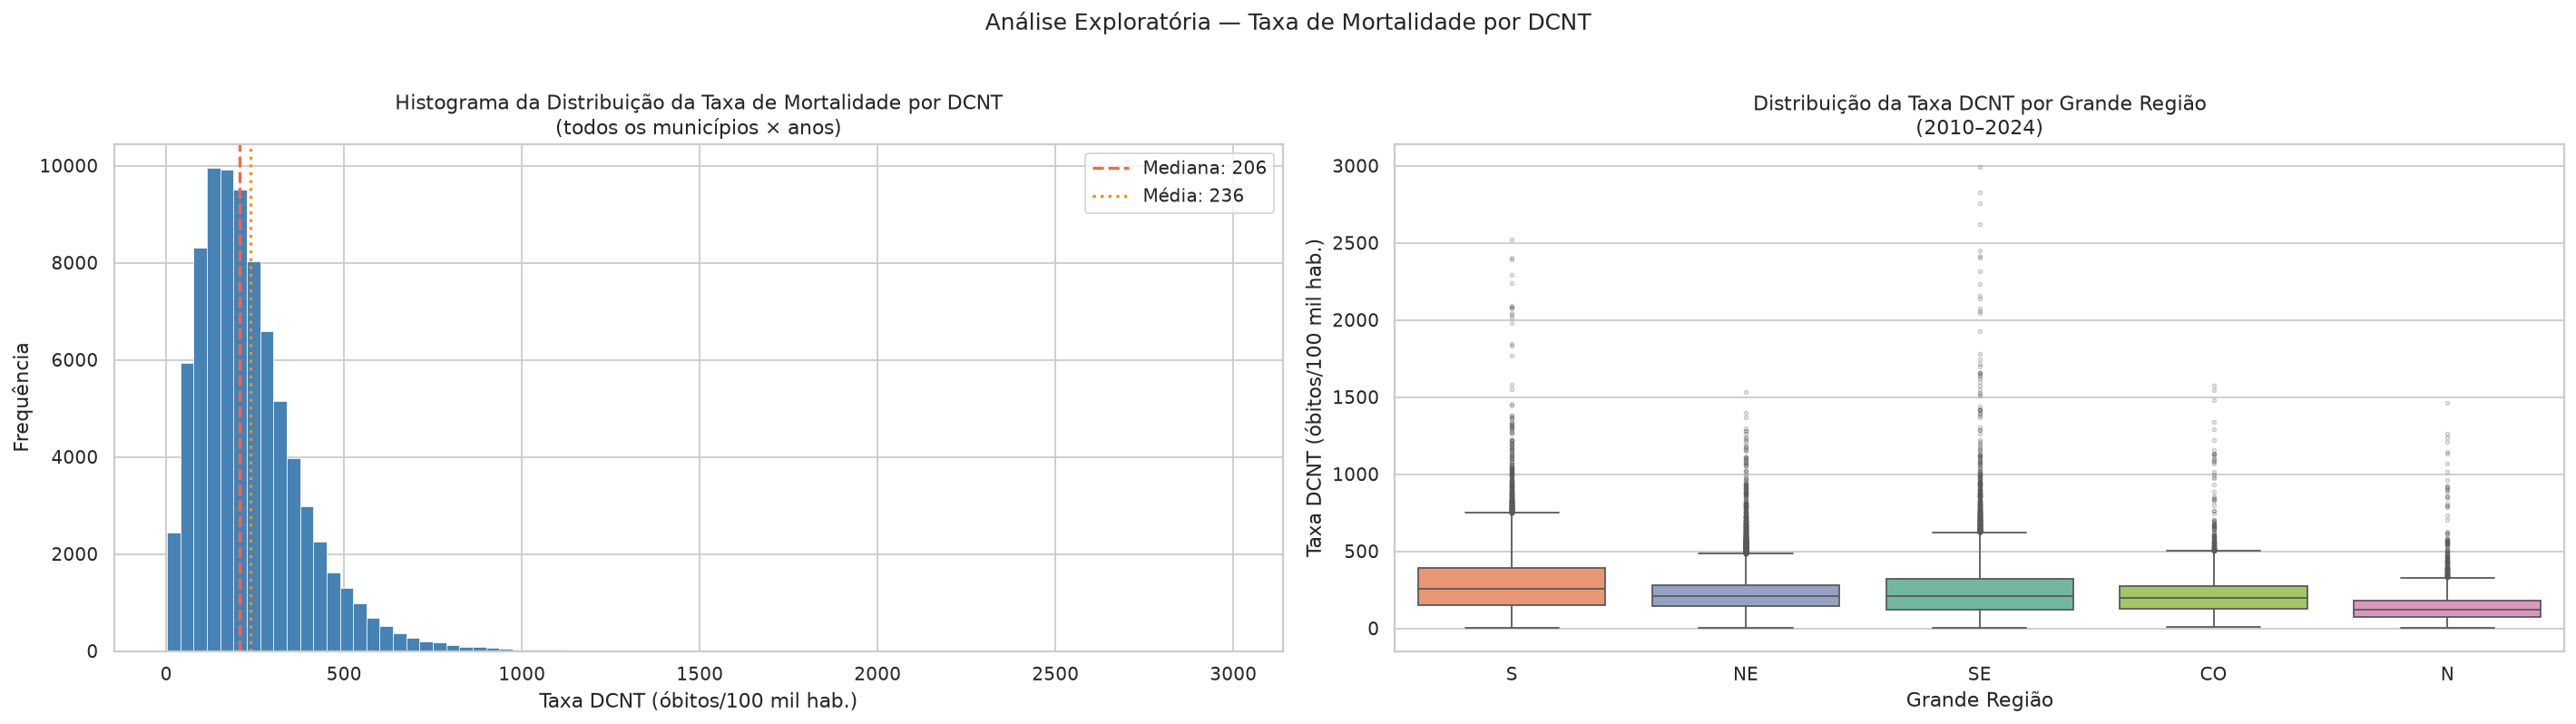

✅ Figura salva: dados/3-ouro/eda_distribuicao.png


In [5]:
# ── Semana 4 / 4.2: EDA — Distribuições ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(22, 6))

# Histograma geral
ax1 = axes[0]
ax1.hist(taxa['taxa_dcnt_100k'], bins=80, color='steelblue', edgecolor='white', linewidth=0.4)
ax1.axvline(taxa['taxa_dcnt_100k'].median(), color='tomato', lw=1.8, linestyle='--', label=f'Mediana: {taxa["taxa_dcnt_100k"].median():.0f}')
ax1.axvline(taxa['taxa_dcnt_100k'].mean(), color='darkorange', lw=1.8, linestyle=':', label=f'Média: {taxa["taxa_dcnt_100k"].mean():.0f}')
ax1.set_xlabel('Taxa DCNT (óbitos/100 mil hab.)')
ax1.set_ylabel('Frequência')
ax1.set_title('Histograma da Distribuição da Taxa de Mortalidade por DCNT\n(todos os municípios × anos)')
ax1.legend()

# Boxplot por região
ORDEM = taxa.groupby('sigla_regiao')['taxa_dcnt_100k'].median().sort_values(ascending=False).index.tolist()
ax2 = axes[1]
sns.boxplot(data=taxa, x='sigla_regiao', y='taxa_dcnt_100k', hue='sigla_regiao', order=ORDEM, palette='Set2', legend=False, flierprops=dict(marker='o', markersize=2, alpha=0.3), ax=ax2)
ax2.set_xlabel('Grande Região')
ax2.set_ylabel('Taxa DCNT (óbitos/100 mil hab.)')
ax2.set_title('Distribuição da Taxa DCNT por Grande Região\n(2010–2024)')

plt.suptitle('Análise Exploratória — Taxa de Mortalidade por DCNT', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OURO_DIR / 'eda_distribuicao.png', dpi=130, bbox_inches='tight')
plt.show()

print('✅ Figura salva: dados/3-ouro/eda_distribuicao.png')


### 🏆 Célula 4.3 — EDA: Ranking Municipal de Taxa DCNT

Identifica os **10 municípios com maior** e os **10 com menor** taxa média de mortalidade por DCNT (óbitos/100 mil hab.), calculada como a média de todos os anos disponíveis (2010–2024).  

> **Atenção interpretativa:** municípios muito pequenos podem ter taxas elevadas ou muito baixas por flutuação aleatória decorrente do baixo volume populacional. O ranking reflete a média histórica sem ponderação por porte.


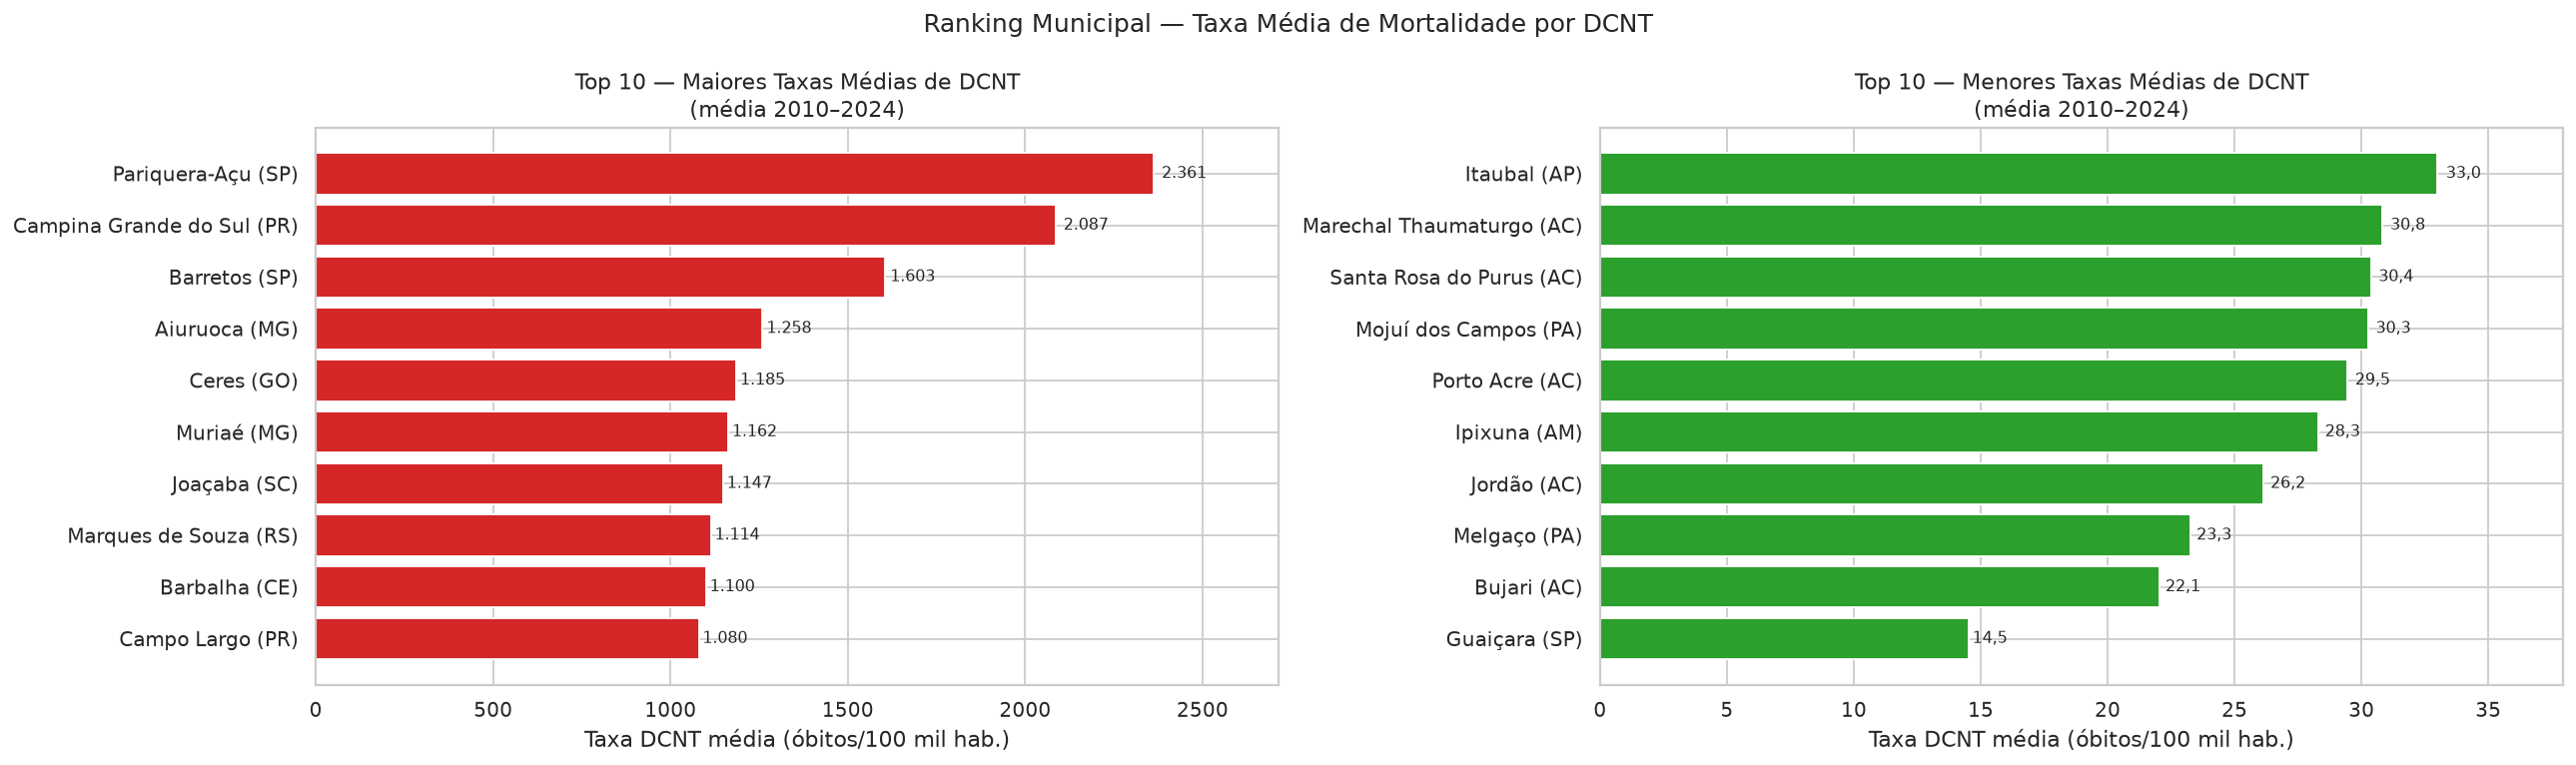

✅ Figura salva: dados/3-ouro/eda_ranking_municipios.png

── Top 10 municípios Maior Taxa Média ────────────────────────────────────────────────────
  Pariquera-Açu                       (SP) — 2.361/100k
  Campina Grande do Sul               (PR) — 2.087/100k
  Barretos                            (SP) — 1.603/100k
  Aiuruoca                            (MG) — 1.258/100k
  Ceres                               (GO) — 1.185/100k
  Muriaé                              (MG) — 1.162/100k
  Joaçaba                             (SC) — 1.147/100k
  Marques de Souza                    (RS) — 1.114/100k
  Barbalha                            (CE) — 1.100/100k
  Campo Largo                         (PR) — 1.080/100k

── Top 10 municípios Menor Taxa Média ─────────────────────────────────────────────────
  Guaiçara                            (SP) — 14,5/100k
  Bujari                              (AC) — 22,1/100k
  Melgaço                             (PA) — 23,3/100k
  Jordão                              

In [6]:
# ── Semana 4 / 4.3: EDA — Ranking Municipal (Top/Bottom 10) ─────────────────
media_mun = (
    taxa.groupby(['codigo_municipio', 'nome_municipio', 'sigla_estado', 'sigla_regiao'], as_index=False)
    ['taxa_dcnt_100k'].mean()
    .sort_values('taxa_dcnt_100k', ascending=False)
    .reset_index(drop=True)
)

top10    = media_mun.head(10).copy()
bottom10 = media_mun[media_mun['taxa_dcnt_100k'] > 0].tail(10).sort_values('taxa_dcnt_100k').copy()

def _label(row):
    return f"{row['nome_municipio']} ({row['sigla_estado']})"

fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# ── Top 10
labels_top = [_label(r) for _, r in top10.iterrows()]
bars = axes[0].barh(labels_top, top10['taxa_dcnt_100k'], color='#d62728')
axes[0].invert_yaxis()
axes[0].set_xlabel('Taxa DCNT média (óbitos/100 mil hab.)')
axes[0].set_title('Top 10 — Maiores Taxas Médias de DCNT\n(média 2010–2024)', fontsize=12)
for bar, val in zip(bars, top10['taxa_dcnt_100k']):
    axes[0].text(bar.get_width() * 1.01, bar.get_y() + bar.get_height() / 2,
                 f'{br(val)}', va='center', fontsize=9)
axes[0].margins(x=0.15)

# ── Bottom 10
labels_bot = [_label(r) for _, r in bottom10.iterrows()]
bars = axes[1].barh(labels_bot, bottom10['taxa_dcnt_100k'], color='#2ca02c')
axes[1].set_xlabel('Taxa DCNT média (óbitos/100 mil hab.)')
axes[1].set_title('Top 10 — Menores Taxas Médias de DCNT\n(média 2010–2024)', fontsize=12)
for bar, val in zip(bars, bottom10['taxa_dcnt_100k']):
    axes[1].text(bar.get_width() * 1.01, bar.get_y() + bar.get_height() / 2,
                 f'{br(val, 1)}', va='center', fontsize=9)
axes[1].margins(x=0.15)

plt.suptitle('Ranking Municipal — Taxa Média de Mortalidade por DCNT', fontsize=14)
plt.tight_layout()
plt.savefig(OURO_DIR / 'eda_ranking_municipios.png', dpi=130, bbox_inches='tight')
plt.show()

print('✅ Figura salva: dados/3-ouro/eda_ranking_municipios.png')
print()
print('── Top 10 municípios Maior Taxa Média ────────────────────────────────────────────────────')
for _, r in top10.iterrows():
    print(f"  {r['nome_municipio']:<35s} ({r['sigla_estado']}) — {br(r['taxa_dcnt_100k'])}/100k")
print()
print('── Top 10 municípios Menor Taxa Média ─────────────────────────────────────────────────')
for _, r in bottom10.iterrows():
    print(f"  {r['nome_municipio']:<35s} ({r['sigla_estado']}) — {br(r['taxa_dcnt_100k'], 1)}/100k")


### 📈 Célula 4.4 — EDA: Evolução Temporal por Região

Taxa DCNT média nacional e por grande região, de 2010 a 2024.
O período 2020–2021 é marcado para destacar o impacto da pandemia de COVID-19.


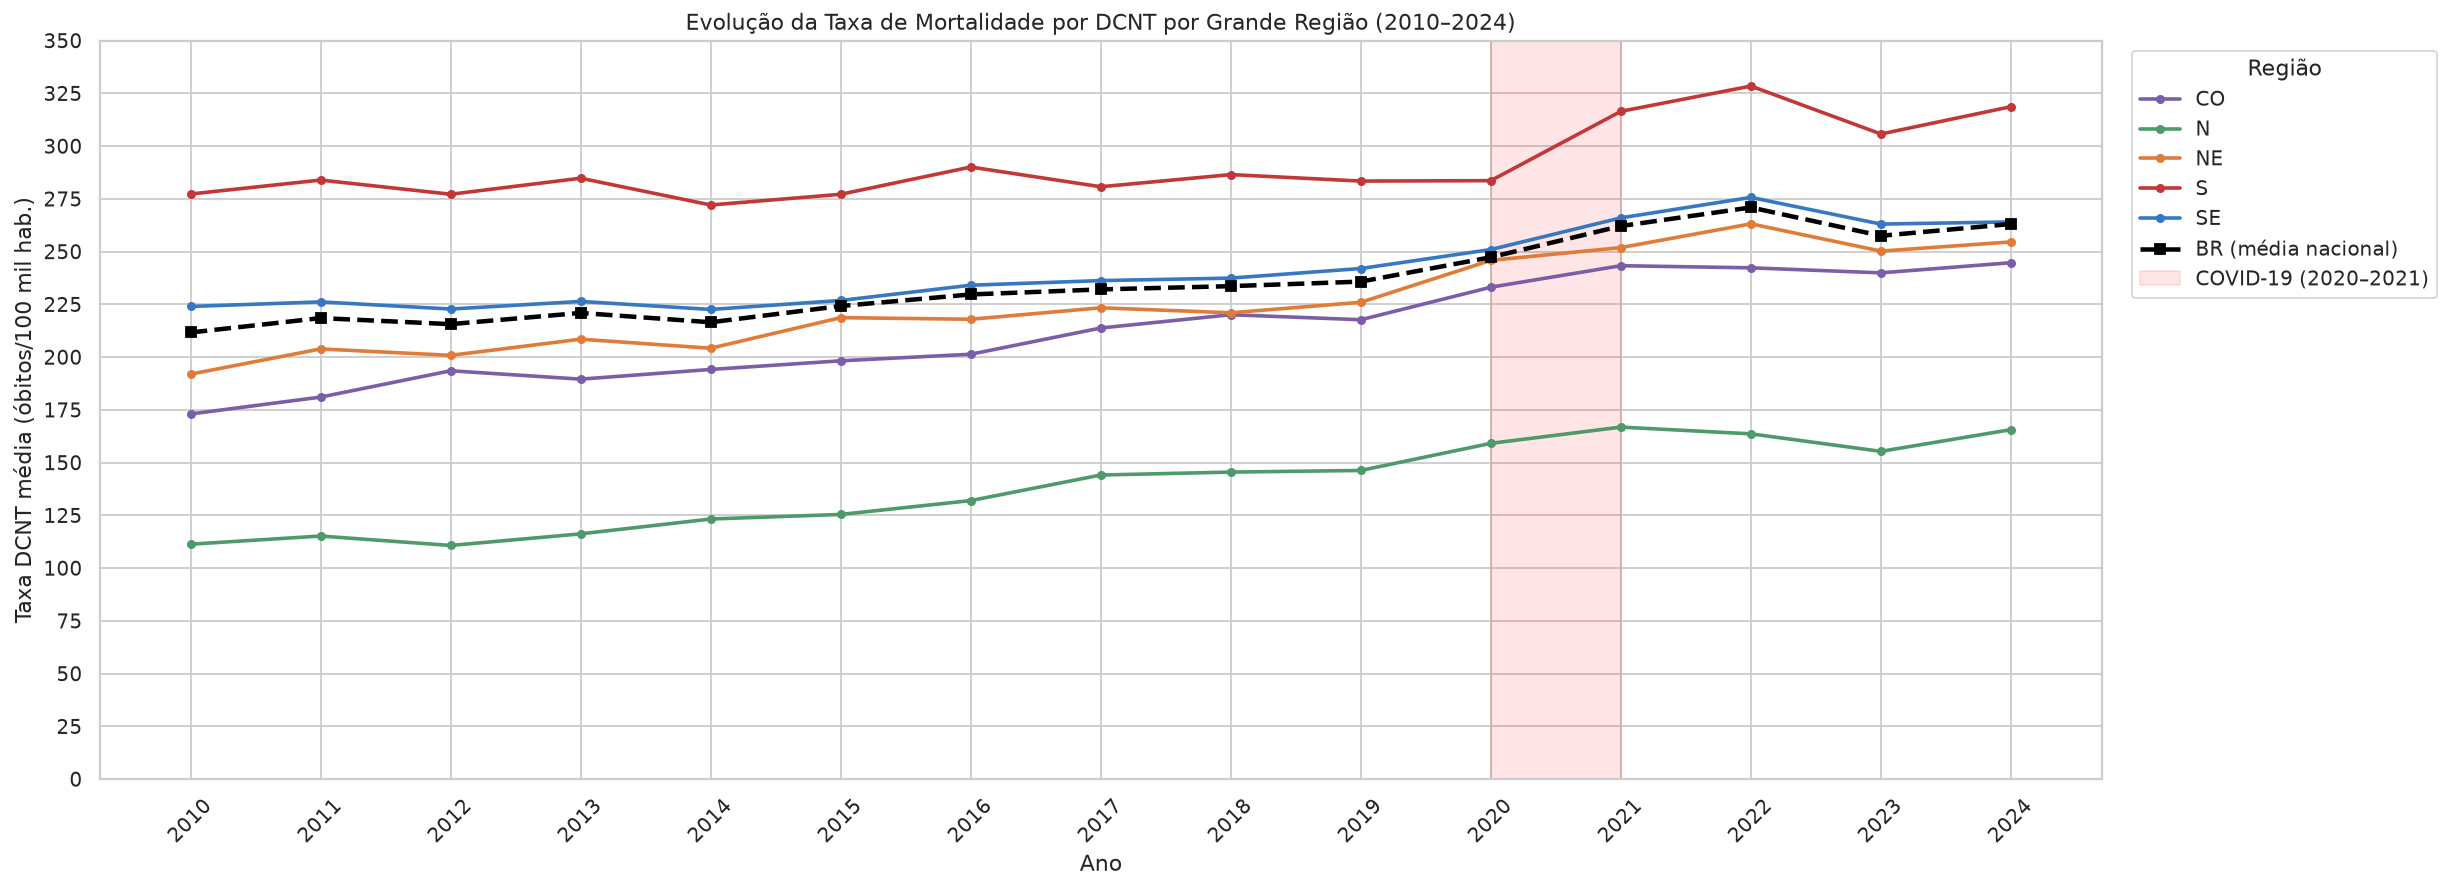

✅ Figura salva: dados/3-ouro/eda_temporal.png


In [7]:
# ── Semana 4 / 4.4: EDA — Evolução Temporal ──────────────────────────────────
temporal_reg = (taxa.groupby(['exercicio', 'sigla_regiao'])
                ['taxa_dcnt_100k'].mean().reset_index())
temporal_br  = (taxa.groupby('exercicio')['taxa_dcnt_100k']
                    .mean().reset_index()
                    .assign(sigla_regiao='BR (média)'))

fig, ax = plt.subplots(figsize=(19, 7))

CORES_REG = {'N':'#4e9a6b', 'NE':'#e07b39', 'CO':'#7b5ea7', 'SE':'#3778c2', 'S':'#c23737'}

for reg, grp in temporal_reg.groupby('sigla_regiao'):
    ax.plot(grp['exercicio'], grp['taxa_dcnt_100k'],
            marker='o', markersize=4, lw=2, label=reg, color=CORES_REG.get(reg))

ax.plot(temporal_br['exercicio'], temporal_br['taxa_dcnt_100k'],
        marker='s', markersize=5, lw=2.5, linestyle='--',
        color='black', label='BR (média nacional)')

# Destaca período COVID
ax.axvspan(2020, 2021, alpha=0.10, color='red', label='COVID-19 (2020–2021)')

ax.set_xlabel('Ano')
ax.set_ylabel('Taxa DCNT média (óbitos/100 mil hab.)')
ax.set_title('Evolução da Taxa de Mortalidade por DCNT por Grande Região (2010–2024)')
ax.set_xticks(range(2010, 2025))
ax.set_yticks(range(0, 500, 25))
ax.set_ylim(0, 350)
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Região', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig(OURO_DIR / 'eda_temporal.png', dpi=130, bbox_inches='tight')
plt.show()
print('✅ Figura salva: dados/3-ouro/eda_temporal.png')


### 🏥 Célula 4.5 — EDA: Breakdown por Grupo de DCNT

Agrega os arquivos `sim_ouro` para calcular a proporção de óbitos de cada grupo de DCNT
(cardiovascular, neoplasia, respiratória, diabetes) por grande região.


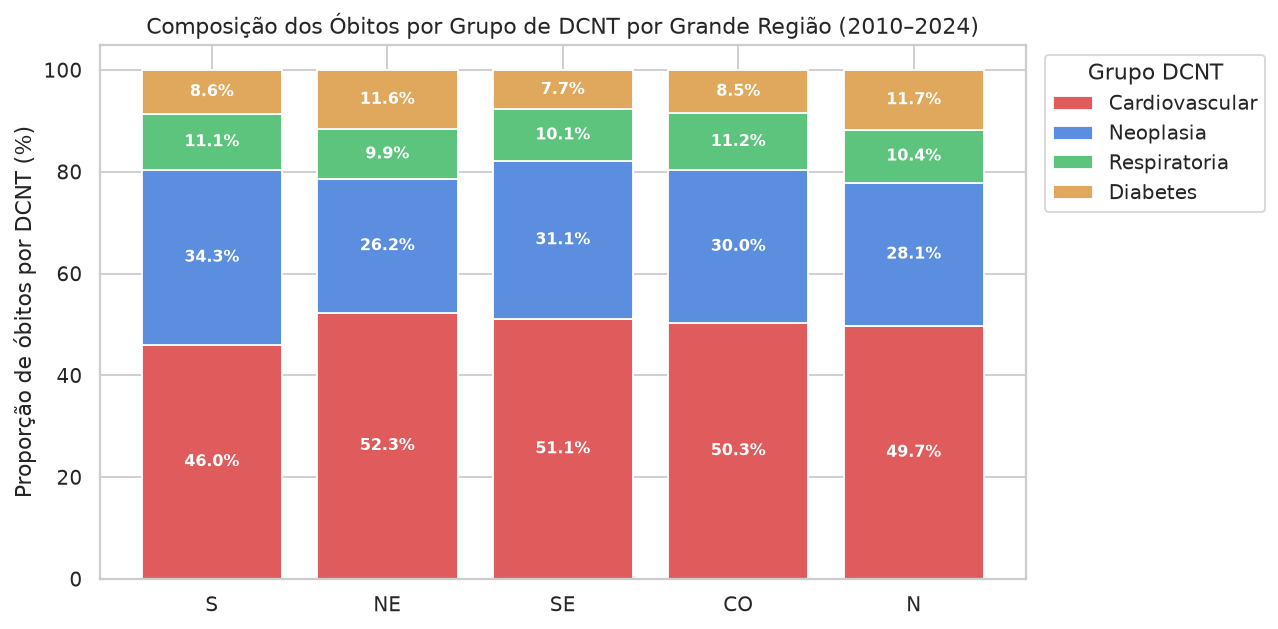

✅ Figura salva: dados/3-ouro/eda_breakdown_dcnt.png

── Proporção (%) por Região ─────────────────────────────────────────────
grupo         Cardiovascular  Diabetes  Neoplasia  Respiratoria
sigla_regiao                                                   
S                  46,000000  8,600000  34,300000     11,100000
NE                 52,300000 11,600000  26,200000      9,900000
SE                 51,100000  7,700000  31,100000     10,100000
CO                 50,300000  8,500000  30,000000     11,200000
N                  49,700000 11,700000  28,100000     10,400000


In [8]:
# ── Semana 4 / 4.5: EDA — Breakdown por Grupo DCNT ───────────────────────────
import re

OURO_SIM = OURO_DIR / 'SIM'

def grupo_dcnt(cid: str) -> str:
    c = str(cid).strip()
    if re.match(r"^I", c):   return 'Cardiovascular'
    if re.match(r"^C", c):   return 'Neoplasia'
    if re.match(r"^J[3-9]|^J[1-9][0-9]", c) and not c.startswith('J36'):
        return 'Respiratoria'
    if re.match(r"^E1[0-4]", c): return 'Diabetes'
    return None

frames = []
for ano in ANOS:
    arq = OURO_SIM / str(ano) / f'sim_ouro_{ano}.parquet'
    if not arq.exists():
        continue
    df = pd.read_parquet(arq, columns=['dcnt','codigo_cid10','sigla_regiao','obitos'])
    df = df[df['dcnt'] == 'S'].copy()
    df['grupo'] = df['codigo_cid10'].apply(grupo_dcnt)
    df = df[df['grupo'].notna()]
    frames.append(df[['sigla_regiao','grupo','obitos']])

sim_dcnt = pd.concat(frames, ignore_index=True)
breakdown = (sim_dcnt.groupby(['sigla_regiao','grupo'])['obitos']
                     .sum()
                     .unstack(fill_value=0))
breakdown_pct = breakdown.div(breakdown.sum(axis=1), axis=0) * 100
breakdown_pct = breakdown_pct.loc[ORDEM]

fig, ax = plt.subplots(figsize=(10, 5))
CORES_GRUPO = {'Cardiovascular':'#e05c5c','Neoplasia':'#5c8ee0',
               'Respiratoria':'#5cc47c','Diabetes':'#e0a85c'}
bottom = np.zeros(len(breakdown_pct))
for grupo in ['Cardiovascular','Neoplasia','Respiratoria','Diabetes']:
    vals = breakdown_pct[grupo].values
    ax.bar(breakdown_pct.index, vals, bottom=bottom,
           label=grupo, color=CORES_GRUPO[grupo])
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v > 4:
            ax.text(i, b + v/2, f'{v:.1f}%', ha='center', va='center',
                    fontsize=9, color='white', fontweight='bold')
    bottom += vals

ax.set_ylabel('Proporção de óbitos por DCNT (%)')
ax.set_title('Composição dos Óbitos por Grupo de DCNT por Grande Região (2010–2024)')
ax.legend(title='Grupo DCNT', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.set_ylim(0, 105)
plt.tight_layout()
plt.savefig(OURO_DIR / 'eda_breakdown_dcnt.png', dpi=130, bbox_inches='tight')
plt.show()
print('✅ Figura salva: dados/3-ouro/eda_breakdown_dcnt.png')

print()
print('── Proporção (%) por Região ─────────────────────────────────────────────')
print(breakdown_pct.round(1).to_string())


---

## 🔵 Clustering — Identificação de Perfis Municipais

Agrupa os 5.570 municípios brasileiros com base em características de mortalidade por DCNT,
aplicando K-Means sobre uma feature matrix derivada dos datasets Ouro.


### 🧱 Célula 5.1 — Clustering: Construção de dataframe com dados da regressão linear

Constrói uma linha por município com as seguintes features:

| Feature | Descrição |
|---|---|
| `taxa_media` | Taxa DCNT média 2010–2024 |
| `tendencia` | Inclinação da reta ajustada à taxa ao longo dos anos (polyfit grau 1) |
| `log_pop_media` | log₁₀ da população média (captura porte do município) |
| `prop_cardiovascular` | Proporção de óbitos DCNT cardiovasculares (2010–2024) |
| `prop_neoplasia` | Proporção de óbitos DCNT por neoplasia |
| `prop_respiratoria` | Proporção de óbitos DCNT respiratórios |
| `prop_diabetes` | Proporção de óbitos DCNT por diabetes |


In [9]:
# ── Semana 4 / 5.1: Feature Matrix ───────────────────────────────────────────
from scipy.stats import linregress

OURO_SIM = OURO_DIR / 'SIM'

# ── Comportamento a partir de taxa_dcnt_municipio ──────────────────────────────────
def calc_tendencia(grupo):
    anos  = grupo['exercicio'].values
    taxas = grupo['taxa_dcnt_100k'].values
    if len(anos) < 3:
        return np.nan
    tendencia, *_ = linregress(anos, taxas)
    return tendencia

feat_taxa = (taxa.groupby('codigo_municipio')
                 .apply(lambda g: pd.Series({
                     'taxa_media'    : g['taxa_dcnt_100k'].mean(),
                     'tendencia'     : calc_tendencia(g),
                     'log_pop_media' : np.log10(g['populacao'].mean()),
                     'nome_municipio': g['nome_municipio'].iloc[0],
                     'sigla_estado'  : g['sigla_estado'].iloc[0],
                     'sigla_regiao'  : g['sigla_regiao'].iloc[0],
                     'nome_regiao'   : g['nome_regiao'].iloc[0],
                 }), include_groups=False)
                 .reset_index())

# ── Proporções por grupo DCNT ─────────────────────────────────────────────────
frames2 = []
for ano in range(2010, 2025):
    arq = OURO_SIM / str(ano) / f'sim_ouro_{ano}.parquet'
    if not arq.exists():
        continue
    df = pd.read_parquet(arq, columns=['dcnt', 'codigo_cid10', 'codigo_municipio', 'obitos'])
    df = df[df['dcnt'] == 'S'].copy()
    df['grupo'] = df['codigo_cid10'].apply(grupo_dcnt)
    df = df[df['grupo'].notna()]
    frames2.append(df[['codigo_municipio', 'grupo', 'obitos']])

sim_mun = pd.concat(frames2, ignore_index=True)

grupo_mun = (sim_mun.groupby(['codigo_municipio', 'grupo'])['obitos']
                    .sum()
                    .unstack(fill_value=0)
                    .reset_index())

total = grupo_mun[['Cardiovascular', 'Neoplasia', 'Respiratoria', 'Diabetes']].sum(axis=1)

# Mapeamento explícito para evitar ambiguidade de encoding em nomes de coluna
COL_MAP = {
    'Cardiovascular' : 'prop_cardiovascular',
    'Neoplasia'      : 'prop_neoplasia',
    'Respiratoria'   : 'prop_respiratoria',
    'Diabetes'       : 'prop_diabetes',
}
for grupo_col, prop_col in COL_MAP.items():
    if grupo_col in grupo_mun.columns:
        grupo_mun[prop_col] = grupo_mun[grupo_col] / total.replace(0, np.nan)

prop_cols = [c for c in grupo_mun.columns if c.startswith('prop_')]
feat_prop  = grupo_mun[['codigo_municipio'] + prop_cols]

# ── Join final ────────────────────────────────────────────────────────────────
features = feat_taxa.merge(feat_prop, on='codigo_municipio', how='left')
features[prop_cols] = features[prop_cols].fillna(features[prop_cols].median())

print(f'Feature matrix : {br(features.shape[0])} municípios × {features.shape[1]} colunas')
print(f'Valores nulos  : {features[["taxa_media","tendencia","log_pop_media"] + prop_cols].isnull().sum().sum()}')
print()
print(features[['taxa_media', 'tendencia', 'log_pop_media'] + prop_cols].describe().round(3).to_string())


Feature matrix : 5.570 municípios × 12 colunas
Valores nulos  : 2

        taxa_media    tendencia  log_pop_media  prop_cardiovascular  prop_neoplasia  prop_respiratoria  prop_diabetes
count 5.570,000000 5.568,000000   5.570,000000         5.570,000000    5.570,000000       5.570,000000   5.570,000000
mean    233,730000     4,269000       4,106000             0,562000        0,226000           0,103000       0,108000
std     141,886000     7,529000       0,509000             0,080000        0,071000           0,042000       0,043000
min      14,526000   -31,808000       2,926000             0,000000        0,000000           0,000000       0,000000
25%     139,296000     0,045000       3,731000             0,508000        0,178000           0,075000       0,080000
50%     202,352000     3,818000       4,053000             0,559000        0,221000           0,100000       0,105000
75%     289,318000     8,009000       4,390000             0,613000        0,269000           0,127000     

### 📈 Célula 4.6 — EDA: Correlações entre Indicadores Municipais

Matriz de correlação (Pearson e Spearman) entre os indicadores que alimentam o clustering:
taxa média, tendência temporal, porte populacional (log) e as proporções por grupo de DCNT.
Além de cumprir a etapa de **correlações** da análise exploratória, o heatmap serve de
**diagnóstico** para a modelagem: como as quatro proporções de DCNT somam ≈1 (dados
composicionais), espera-se forte colinearidade entre elas — a proporção mais redundante
(`DROP_PROP`) é então removida do conjunto de features na etapa de clustering.

- **Saída:** `dados/3-ouro/eda_correlacao.png`

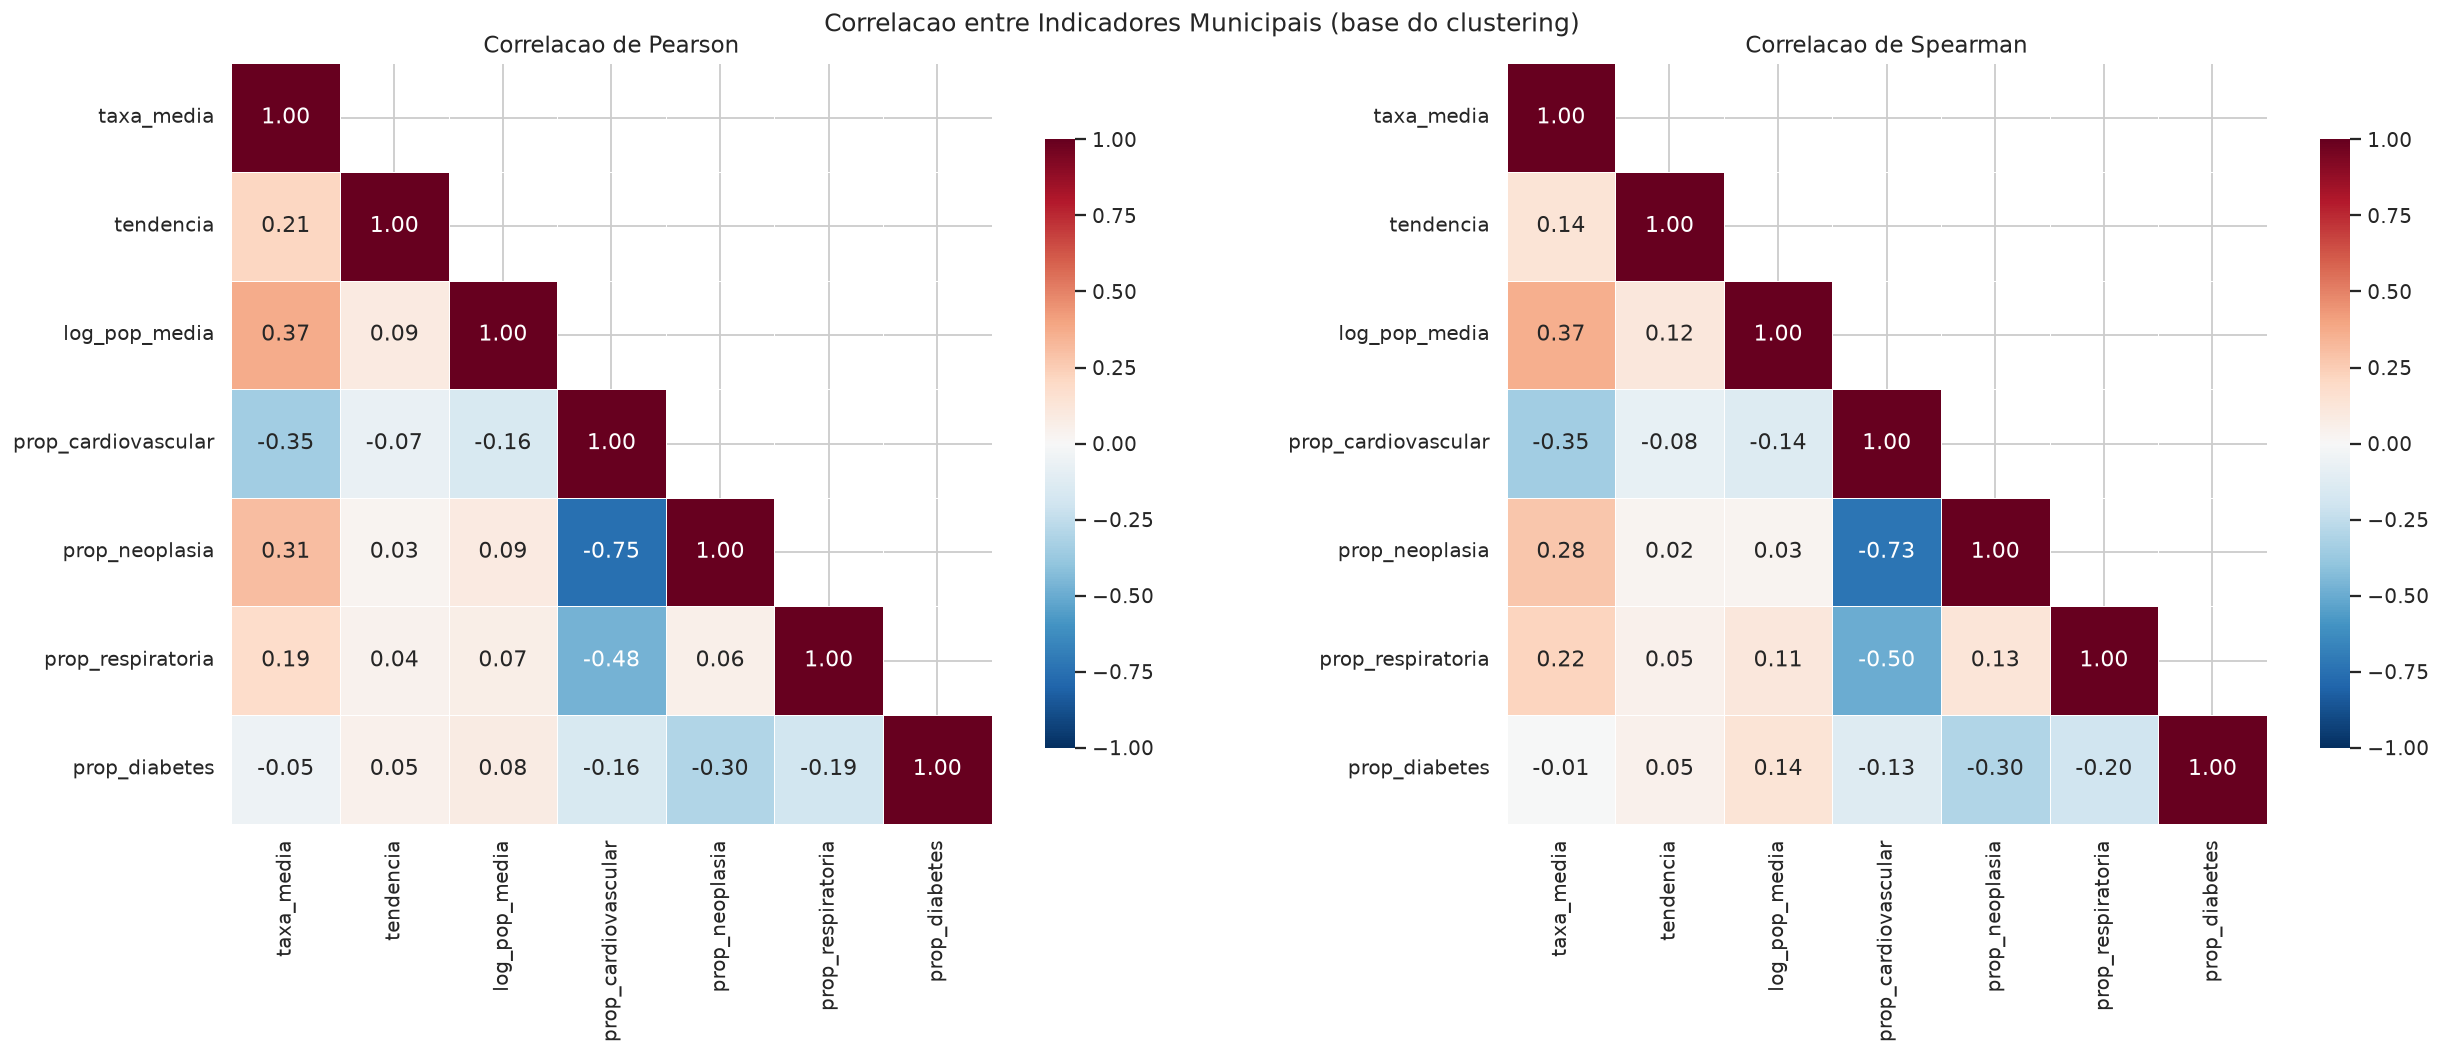

── Colinearidade media entre proporcoes (|corr| media com as demais) ────
prop_cardiovascular   0,463000
prop_neoplasia        0,372000
prop_respiratoria     0,243000
prop_diabetes         0,219000

  -> Proporcao mais redundante (removida do clustering): prop_cardiovascular

── Correlacoes de Pearson com a taxa_media ──────────────────────
log_pop_media          0,370000
prop_cardiovascular   -0,345000
prop_neoplasia         0,310000
tendencia              0,213000
prop_respiratoria      0,187000
prop_diabetes         -0,051000


In [10]:
# ── Semana 4 / 4.6: EDA — Correlações entre Indicadores Municipais ────────────
# Usa a feature matrix COMPLETA (antes do filtro de estabilidade da 5.2).
# Duplo papel: (1) cumpre a etapa de correlacoes da EDA; (2) diagnostica a
# redundancia composicional das proporcoes para escolher DROP_PROP no clustering.

CORR_COLS = ['taxa_media', 'tendencia', 'log_pop_media'] + prop_cols

corr_pearson  = features[CORR_COLS].corr(method='pearson')
corr_spearman = features[CORR_COLS].corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
for ax, corr, titulo in [(axes[0], corr_pearson, 'Pearson'),
                         (axes[1], corr_spearman, 'Spearman')]:
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
                center=0, vmin=-1, vmax=1, square=True, linewidths=.5,
                cbar_kws={'shrink': .8}, ax=ax)
    ax.set_title(f'Correlacao de {titulo}', fontsize=13)
plt.suptitle('Correlacao entre Indicadores Municipais (base do clustering)', fontsize=14)
plt.tight_layout()
plt.savefig(OURO_DIR / 'eda_correlacao.png', dpi=130, bbox_inches='tight')
plt.show()

# ── Diagnostico de redundancia composicional entre as proporcoes ──────────────
# A proporcao mais colinear (maior |correlacao| media com as demais) e a candidata
# a ser removida do conjunto de features do clustering.
prop_corr = features[prop_cols].corr().abs()
_mask_offdiag = ~np.eye(len(prop_cols), dtype=bool)
colinearidade = prop_corr.where(_mask_offdiag).mean()
DROP_PROP = colinearidade.idxmax()

print('── Colinearidade media entre proporcoes (|corr| media com as demais) ────')
print(colinearidade.sort_values(ascending=False).round(3).to_string())
print(f'\n  -> Proporcao mais redundante (removida do clustering): {DROP_PROP}')
print('\n── Correlacoes de Pearson com a taxa_media ──────────────────────')
print(corr_pearson['taxa_media'].drop('taxa_media').sort_values(key=abs, ascending=False).round(3).to_string())

### 📐 Célula 5.2 — Clustering: Normalização e Determinação do k

Aplica `RobustScaler` nas features (robusto a outliers, usa mediana e IQR) e usa
o método Elbow + Silhouette Score para escolher o número ótimo de clusters.
Os dois critérios são comparados explicitamente para verificar convergência.

Antes da normalizacao aplica-se um **filtro de estabilidade**: municipios de porte muito
pequeno tem taxas volateis (denominador populacional baixo) e sao removidos do agrupamento
para nao dominarem a variancia — eles ficam sem rotulo e aparecem em cinza no mapa. Uma das
quatro proporcoes de DCNT tambem e descartada (`DROP_PROP`, diagnosticada na celula 4.6),
pois as proporcoes somam ≈1 e carregam redundancia composicional.

> **Validacao:** por se tratar de tarefa **nao supervisionada**, nao ha separacao treino/teste;
> a qualidade do agrupamento e avaliada por metrica interna (**Silhouette Score**), e o numero
> de clusters e escolhido pela convergencia Elbow/Silhouette combinada a interpretabilidade dos perfis.


── Filtro de estabilidade ─────────────────────────────────
  Criterio         : log_pop_media >= 4.0  (~10,000 hab.)
  Municipios antes : 5.570
  Municipios apos  : 3.103  (removidos 2.467)

  Features (6)  : ['taxa_media', 'tendencia', 'log_pop_media', 'prop_neoplasia', 'prop_respiratoria', 'prop_diabetes']
  Proporcao removida : prop_cardiovascular  (redundancia composicional)



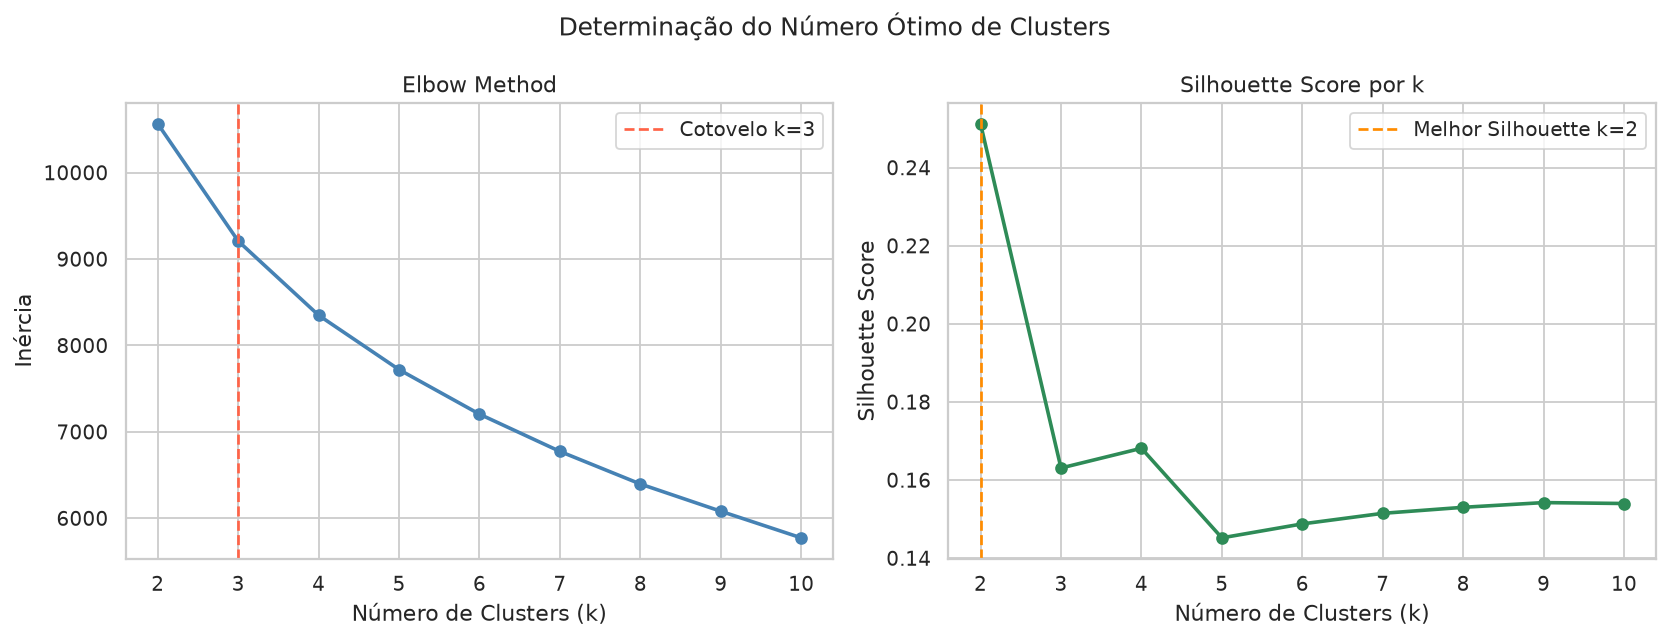

── Convergência entre os critérios ──────────────────────────────────────
  Cotovelo (2ª derivada da inércia) : k = 3
  Silhouette Score máximo            : k = 2  (score = 0.2512)
  ⚠️  Os critérios divergem — adotando Silhouette (k=2) como critério principal

  k= 2  inércia=       10.566,1  silhouette=0.2512  ◄ melhor Silhouette
  k= 3  inércia=        9.209,0  silhouette=0.1631  ◄ cotovelo
  k= 4  inércia=        8.350,0  silhouette=0.1681
  k= 5  inércia=        7.720,6  silhouette=0.1452
  k= 6  inércia=        7.205,3  silhouette=0.1488
  k= 7  inércia=        6.773,9  silhouette=0.1515
  k= 8  inércia=        6.396,8  silhouette=0.1530
  k= 9  inércia=        6.081,4  silhouette=0.1542
  k=10  inércia=        5.773,4  silhouette=0.1540


In [11]:
# ── Semana 4 / 5.2: Elbow Method e Silhouette ────────────────────────────────
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ── Filtro de estabilidade ──────────────────────────────────────
# Municipios de baixo porte tem taxa de mortalidade instavel (flutuacao estatistica
# por denominadores populacionais pequenos). Sao removidos do clustering para nao
# dominarem a variancia; ficam sem rotulo e aparecem em cinza no mapa (cel. 6.1).
LIMIAR_LOGPOP = 4.0  # log10(pop. media) >= 4.0  ->  ~10 mil habitantes  (tunavel)
_n_antes = len(features)
features = features[features['log_pop_media'] >= LIMIAR_LOGPOP].reset_index(drop=True)
print('── Filtro de estabilidade ─────────────────────────────────')
print(f'  Criterio         : log_pop_media >= {LIMIAR_LOGPOP}  (~{10**LIMIAR_LOGPOP:,.0f} hab.)')
print(f'  Municipios antes : {br(_n_antes)}')
print(f'  Municipios apos  : {br(len(features))}  (removidos {br(_n_antes - len(features))})')
print()

# ── Conjunto de features (remove a proporcao redundante diagnosticada na 4.6) ──
# DROP_PROP vem da analise de colinearidade composicional da celula 4.6.
FEAT_COLS = ['taxa_media', 'tendencia', 'log_pop_media'] + [p for p in prop_cols if p != DROP_PROP]
print(f'  Features ({len(FEAT_COLS)})  : {FEAT_COLS}')
print(f'  Proporcao removida : {DROP_PROP}  (redundancia composicional)')
print()

# Imputa os raros NaN (municípios sem histórico suficiente) com a mediana da coluna
imputer = SimpleImputer(strategy='median')
X_imp = imputer.fit_transform(features[FEAT_COLS].values)
scaler = RobustScaler()
X = scaler.fit_transform(X_imp)

inertias, silhouettes = [], []
K_RANGE = range(2, 11)

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=15)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels, sample_size=5000, random_state=42))

# Cotovelo pela 2ª derivada da inércia (proxy de curvatura máxima)
diffs2 = np.diff(np.diff(inertias))
elbow_k = list(K_RANGE)[int(np.argmax(np.abs(diffs2))) + 1]
best_k  = list(K_RANGE)[int(np.argmax(silhouettes))]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(list(K_RANGE), inertias, 'o-', color='steelblue', lw=2)
ax1.axvline(elbow_k, color='tomato', lw=1.5, linestyle='--', label=f'Cotovelo k={elbow_k}')
ax1.set_xlabel('Número de Clusters (k)')
ax1.set_ylabel('Inércia')
ax1.set_title('Elbow Method')
ax1.set_xticks(list(K_RANGE))
ax1.legend()

ax2.plot(list(K_RANGE), silhouettes, 'o-', color='seagreen', lw=2)
ax2.axvline(best_k, color='darkorange', lw=1.5, linestyle='--', label=f'Melhor Silhouette k={best_k}')
ax2.set_xlabel('Número de Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score por k')
ax2.set_xticks(list(K_RANGE))
ax2.legend()

plt.suptitle('Determinação do Número Ótimo de Clusters', fontsize=14)
plt.tight_layout()
plt.savefig(OURO_DIR / 'clustering_elbow.png', dpi=130, bbox_inches='tight')
plt.show()

print('── Convergência entre os critérios ──────────────────────────────────────')
print(f'  Cotovelo (2ª derivada da inércia) : k = {elbow_k}')
print(f'  Silhouette Score máximo            : k = {best_k}  (score = {max(silhouettes):.4f})')
if elbow_k == best_k:
    print(f'  ✅ Os dois critérios convergem para k = {best_k}')
else:
    print(f'  ⚠️  Os critérios divergem — adotando Silhouette (k={best_k}) como critério principal')
print()
for k, ine, sil in zip(K_RANGE, inertias, silhouettes):
    tags = []
    if k == elbow_k: tags.append('cotovelo')
    if k == best_k:  tags.append('melhor Silhouette')
    tag = f'  ◄ {', '.join(tags)}' if tags else ''
    print(f'  k={k:2d}  inércia={br(ine, 1):>15s}  silhouette={sil:.4f}{tag}')


### 🎯 Célula 5.3 — Clustering: K-Means e Análise dos Clusters

Aplica K-Means com o k ótimo identificado, analisa o perfil de cada cluster e
produz um scatter plot PCA 2D para visualização.


── Avaliação do Modelo Final ────────────────────────────────────────────
  Silhouette Score (k=2): 0.2505

── Perfil dos Clusters ──────────────────────────────────────────────────
           n_municipios  taxa_media  tendencia  log_pop_media  prop_neoplasia  prop_respiratoria  prop_diabetes
Cluster 0          2192  203,187000   4,313000       4,324000        0,206000           0,096000       0,123000
Cluster 1           911  420,350000   6,450000       4,764000        0,274000           0,129000       0,092000

── Municípios por Cluster × Região ─────────────────────────────────────
sigla_regiao   CO    N    NE    S   SE
cluster                               
Cluster 0     165  271  1047  214  495
Cluster 1      60   22   149  280  400


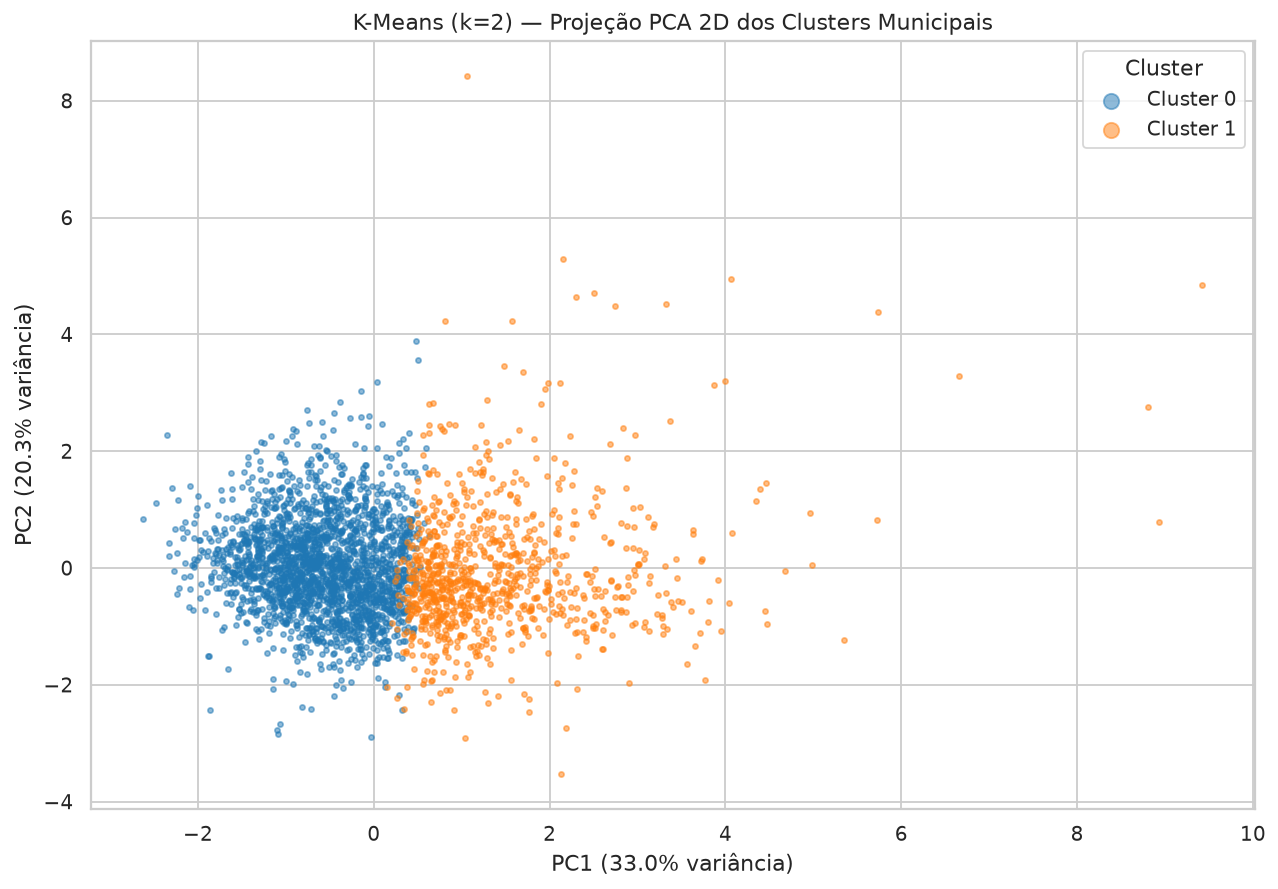

✅ Variância explicada pelos 2 PCs: 53.3%
✅ Arquivo salvo: dados/3-ouro/municipios_clusters.parquet


In [12]:
# ── Semana 4 / 5.3: K-Means e Análise dos Clusters ───────────────────────────
from sklearn.decomposition import PCA

K_FINAL = best_k  # use best_k da célula anterior; pode sobrescrever aqui se preferir

km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=20)
features['cluster'] = km_final.fit_predict(X)

score_final = silhouette_score(X, features['cluster'], sample_size=5000, random_state=42)
print(f'── Avaliação do Modelo Final ────────────────────────────────────────────')
print(f'  Silhouette Score (k={K_FINAL}): {score_final:.4f}')
print()

# ── Perfil de cada cluster ────────────────────────────────────────────────────
perfil = (features.groupby('cluster')[FEAT_COLS]
                  .mean()
                  .round(3))
perfil.insert(0, 'n_municipios', features.groupby('cluster').size())
perfil.index = [f'Cluster {i}' for i in perfil.index]

print('── Perfil dos Clusters ──────────────────────────────────────────────────')
print(perfil.to_string())
print()
print('── Municípios por Cluster × Região ─────────────────────────────────────')
cross = (features.groupby(['cluster','sigla_regiao']).size()
                 .unstack(fill_value=0)
                 .rename(index=lambda i: f'Cluster {i}'))
print(cross.to_string())

# ── PCA 2D ────────────────────────────────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X)

PALETTE = sns.color_palette('tab10', K_FINAL)

fig, ax = plt.subplots(figsize=(10, 7))
for c in range(K_FINAL):
    mask = features['cluster'] == c
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               s=8, alpha=0.5, color=PALETTE[c], label=f'Cluster {c}')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variância)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variância)')
ax.set_title(f'K-Means (k={K_FINAL}) — Projeção PCA 2D dos Clusters Municipais')
ax.legend(title='Cluster', markerscale=3)
plt.tight_layout()
plt.savefig(OURO_DIR / 'clustering_pca.png', dpi=130, bbox_inches='tight')
plt.show()
print(f'✅ Variância explicada pelos 2 PCs: {pca.explained_variance_ratio_.sum()*100:.1f}%')

# Salva dataset com clusters
features.to_parquet(OURO_DIR / 'municipios_clusters.parquet', index=False)
features.to_csv(OURO_DIR / 'municipios_clusters.csv', index=False)
print('✅ Arquivo salvo: dados/3-ouro/municipios_clusters.parquet')


### 🔬 Célula 5.4 — Avaliação de Modelos Alternativos de Clustering

Compara o K-Means (k=2) com três paradigmas diferentes — **Aglomerativo (Ward)**, **Gaussian Mixture (GMM)** e **DBSCAN** — sobre a mesma matriz de features escalonada (`X`). A avaliação usa três métricas internas complementares:

| Métrica | Direção | O que mede |
|---|---|---|
| Silhouette | ↑ melhor | Coesão vs. separação dos clusters |
| Davies-Bouldin | ↓ melhor | Razão dispersão intra / distância inter-cluster |
| Calinski-Harabasz | ↑ melhor | Variância entre / dentro dos clusters |

O **dendrograma** (Ward) revela se há um corte hierárquico natural, e o painel **PCA 2×2** mostra a partição de cada modelo. O modelo com melhor Silhouette (entre os de partição limpa) é **adotado como final** e passa a alimentar o mapa (6.1) e o perfil (6.2). O DBSCAN entra como **diagnóstico de densidade** (detecta ruído e *continuum*), não sendo adotado se não produzir partição válida.

- **Saídas:** `dados/3-ouro/clustering_comparacao.png`, `dados/3-ouro/clustering_dendrograma.png`

── Comparacao de Modelos de Clustering ──────────────────────────────────
                     n_clusters  silhouette  davies_bouldin  calinski_harabasz                   obs
modelo                                                                                              
K-Means                       2    0,250000        1,750000         790,888000                      
Aglomerativo (Ward)           2    0,183000        2,069000         608,581000                      
GMM                           5    0,083000        2,362000         341,537000                      
DBSCAN                        1         NaN             NaN                NaN  eps=1.17, ruido=4.0%



  -> Modelo final adotado: K-Means  (k=2, Silhouette=0.2505)
  OK: K-Means permanece o melhor — escolha da 5.3 confirmada.


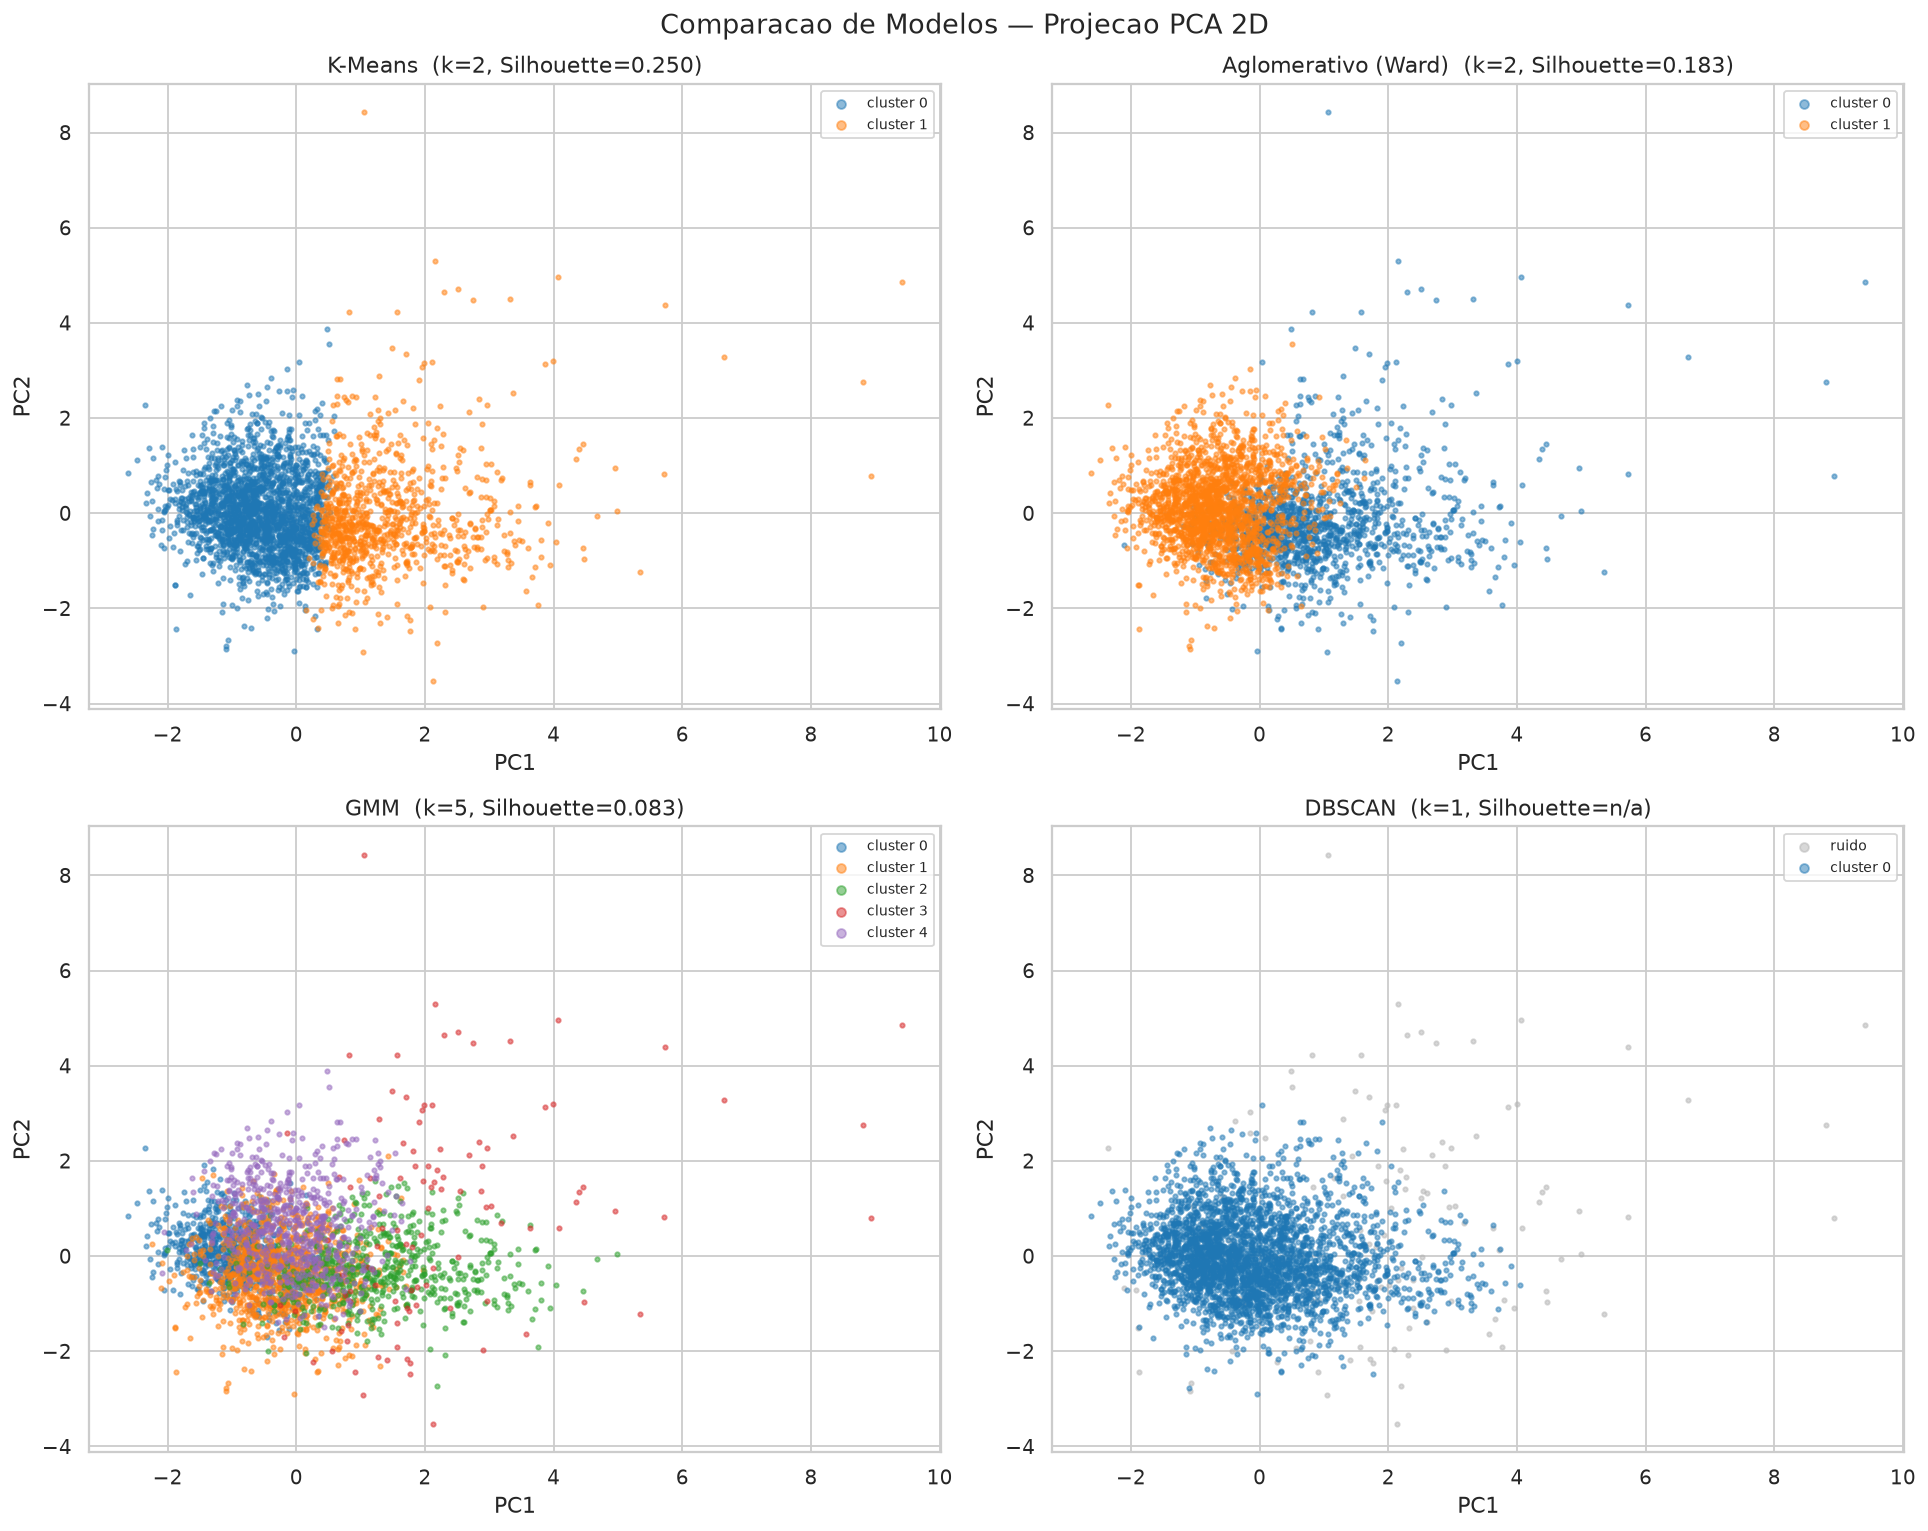

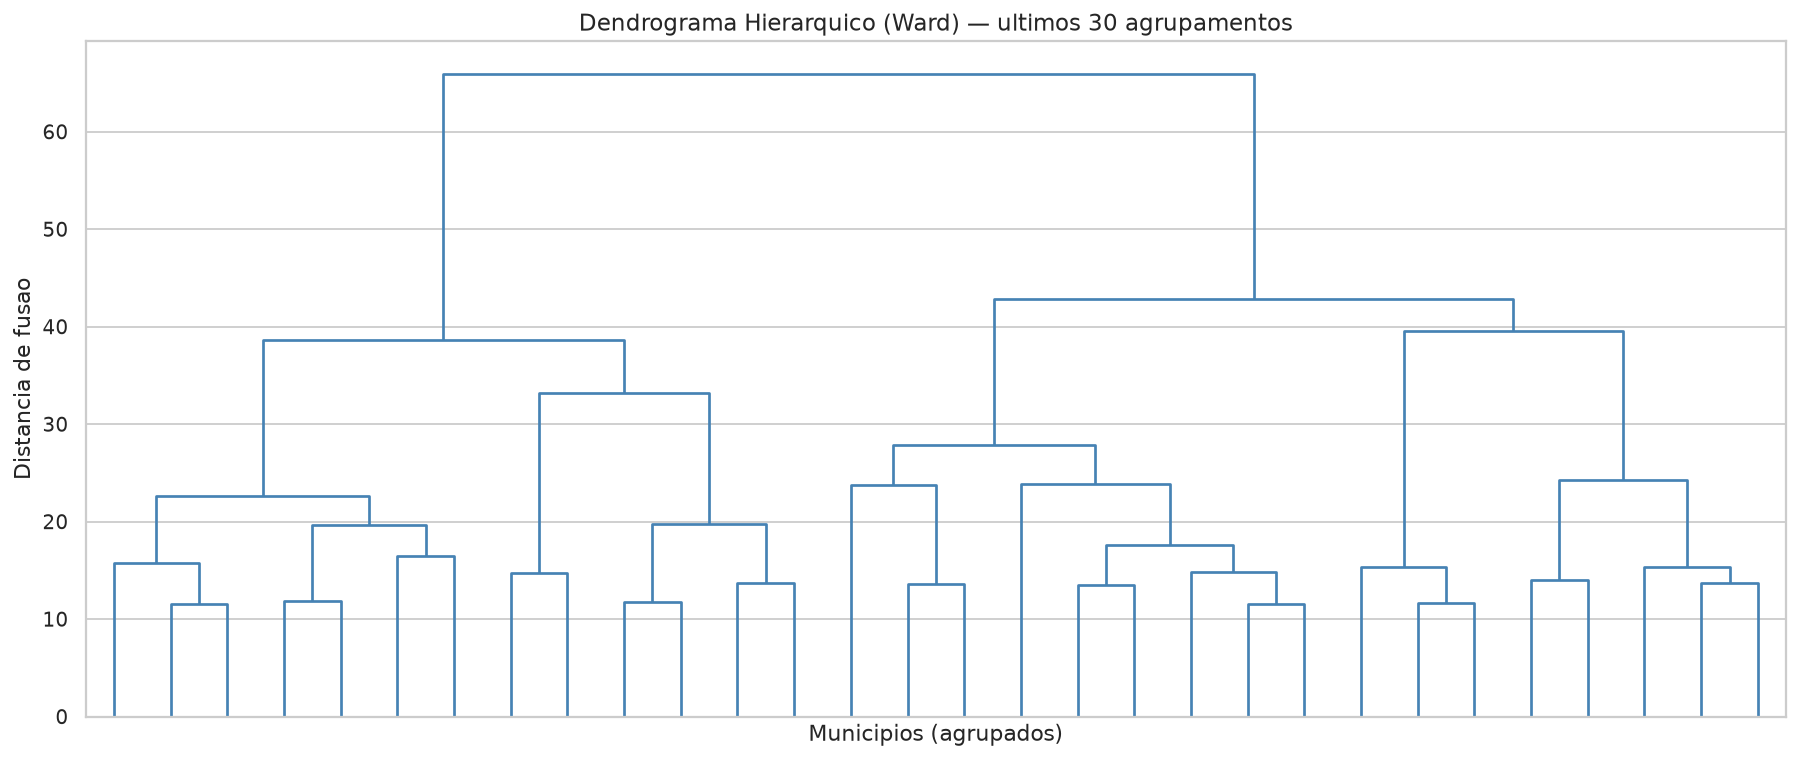

In [13]:
# ── Semana 4 / 5.4: Avaliação de Modelos Alternativos ────────────────────────
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import linkage, dendrogram

def _metricas(Xm, labels):
    labels = np.asarray(labels)
    mask = labels != -1                       # ignora ruido (DBSCAN)
    if len(set(labels[mask])) < 2:
        return np.nan, np.nan, np.nan
    Xv, lv = Xm[mask], labels[mask]
    sil = silhouette_score(Xv, lv, sample_size=min(5000, len(lv)), random_state=42)
    return sil, davies_bouldin_score(Xv, lv), calinski_harabasz_score(Xv, lv)

resultados = {}

# 1) K-Means (baseline ja ajustado na 5.3)
lab_km = features['cluster'].to_numpy()
resultados['K-Means'] = {'k': len(set(lab_km)), 'labels': lab_km, 'adotavel': True}

# 2) Aglomerativo (Ward) — varre k, escolhe melhor Silhouette
_melhor = (-1.0, None, None)
for k in range(2, 7):
    lab = AgglomerativeClustering(n_clusters=k, linkage='ward').fit_predict(X)
    s = silhouette_score(X, lab, sample_size=min(5000, len(lab)), random_state=42)
    if s > _melhor[0]:
        _melhor = (s, k, lab)
resultados['Aglomerativo (Ward)'] = {'k': _melhor[1], 'labels': _melhor[2], 'adotavel': True}

# 3) GMM — varre n_components, escolhe por BIC
_bic, _labg, _kg = np.inf, None, None
for k in range(2, 7):
    gm = GaussianMixture(n_components=k, covariance_type='full', random_state=42, n_init=3).fit(X)
    if gm.bic(X) < _bic:
        _bic, _labg, _kg = gm.bic(X), gm.predict(X), k
resultados['GMM'] = {'k': _kg, 'labels': _labg, 'adotavel': True}

# 4) DBSCAN — eps pela heuristica k-distance (diagnostico de densidade)
_ms = 10
_nn = NearestNeighbors(n_neighbors=_ms).fit(X)
_kdist = np.sort(_nn.kneighbors(X)[0][:, -1])
_eps = float(np.percentile(_kdist, 90))
lab_db = DBSCAN(eps=_eps, min_samples=_ms).fit_predict(X)
_ndb = len(set(lab_db) - {-1})
_ruido = float((lab_db == -1).mean() * 100)
resultados['DBSCAN'] = {'k': _ndb, 'labels': lab_db, 'adotavel': _ndb >= 2,
                        'extra': f'eps={_eps:.2f}, ruido={_ruido:.1f}%'}

# ── Tabela comparativa ───────────────────────────────────────────────────────
_linhas = []
for nome, info in resultados.items():
    sil, dbi, chi = _metricas(X, info['labels'])
    _linhas.append({'modelo': nome, 'n_clusters': info['k'], 'silhouette': sil,
                    'davies_bouldin': dbi, 'calinski_harabasz': chi, 'obs': info.get('extra', '')})
tabela_modelos = pd.DataFrame(_linhas).set_index('modelo')
print('── Comparacao de Modelos de Clustering ──────────────────────────────────')
print(tabela_modelos.round(3).to_string())
print()

# ── Selecao do modelo final (melhor Silhouette entre os de particao limpa) ────
_cand = {n: i for n, i in resultados.items() if i['adotavel']}
MODELO_FINAL = max(_cand, key=lambda n: (_metricas(X, _cand[n]['labels'])[0] if not np.isnan(_metricas(X, _cand[n]['labels'])[0]) else -1))
lab_final = np.asarray(resultados[MODELO_FINAL]['labels'])
K_FINAL = len(set(lab_final[lab_final != -1]))
print(f'  -> Modelo final adotado: {MODELO_FINAL}  (k={K_FINAL}, Silhouette={_metricas(X, lab_final)[0]:.4f})')
if MODELO_FINAL != 'K-Means':
    print('  ATENCAO: supera o K-Means — mapa (6.1) e perfil (6.2) passam a usar este modelo.')
else:
    print('  OK: K-Means permanece o melhor — escolha da 5.3 confirmada.')

# Rebind das variaveis canonicas consumidas por 6.1 e 6.2 + re-salva dataset final
features['cluster'] = lab_final
PALETTE = sns.color_palette('tab10', K_FINAL)
features.to_parquet(OURO_DIR / 'municipios_clusters.parquet', index=False)
features.to_csv(OURO_DIR / 'municipios_clusters.csv', index=False)

# ── Figura 1: PCA 2x2 por modelo ─────────────────────────────────────────────
_cores = sns.color_palette('tab10', 10)
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
for ax, (nome, info) in zip(axes.ravel(), resultados.items()):
    lab = np.asarray(info['labels'])
    sil = _metricas(X, lab)[0]
    for c in sorted(set(lab)):
        m = lab == c
        cor = (0.7, 0.7, 0.7) if c == -1 else _cores[c % 10]
        rot = 'ruido' if c == -1 else f'cluster {c}'
        ax.scatter(X_2d[m, 0], X_2d[m, 1], s=6, alpha=0.5, color=cor, label=rot)
    sil_txt = f'{sil:.3f}' if not np.isnan(sil) else 'n/a'
    ax.set_title(f'{nome}  (k={info["k"]}, Silhouette={sil_txt})', fontsize=12)
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.legend(markerscale=2, fontsize=8)
plt.suptitle('Comparacao de Modelos — Projecao PCA 2D', fontsize=15)
plt.tight_layout()
plt.savefig(OURO_DIR / 'clustering_comparacao.png', dpi=130, bbox_inches='tight')
plt.show()

# ── Figura 2: Dendrograma (Ward) ─────────────────────────────────────────────
_Z = linkage(X, method='ward')
fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(_Z, truncate_mode='lastp', p=30, ax=ax,
           color_threshold=0, above_threshold_color='steelblue', no_labels=True)
ax.set_title('Dendrograma Hierarquico (Ward) — ultimos 30 agrupamentos', fontsize=13)
ax.set_xlabel('Municipios (agrupados)'); ax.set_ylabel('Distancia de fusao')
plt.tight_layout()
plt.savefig(OURO_DIR / 'clustering_dendrograma.png', dpi=130, bbox_inches='tight')
plt.show()

---

## 🗺️ Visualizações Finais


### 🗺️ Célula 6.1 — Mapa Coroplético: Taxa DCNT e Clusters

Baixa o shapefile de municípios do IBGE 2022, faz o join com os dados de taxa DCNT
e de clusters, e gera dois mapas lado a lado.


  Shapefile já disponível, pulando download.


  GeoDataFrame: (5572, 5)  CRS: EPSG:4674
  Municípios com cluster : 3.103
  Municípios sem cluster : 2.469 (serão exibidos em cinza)


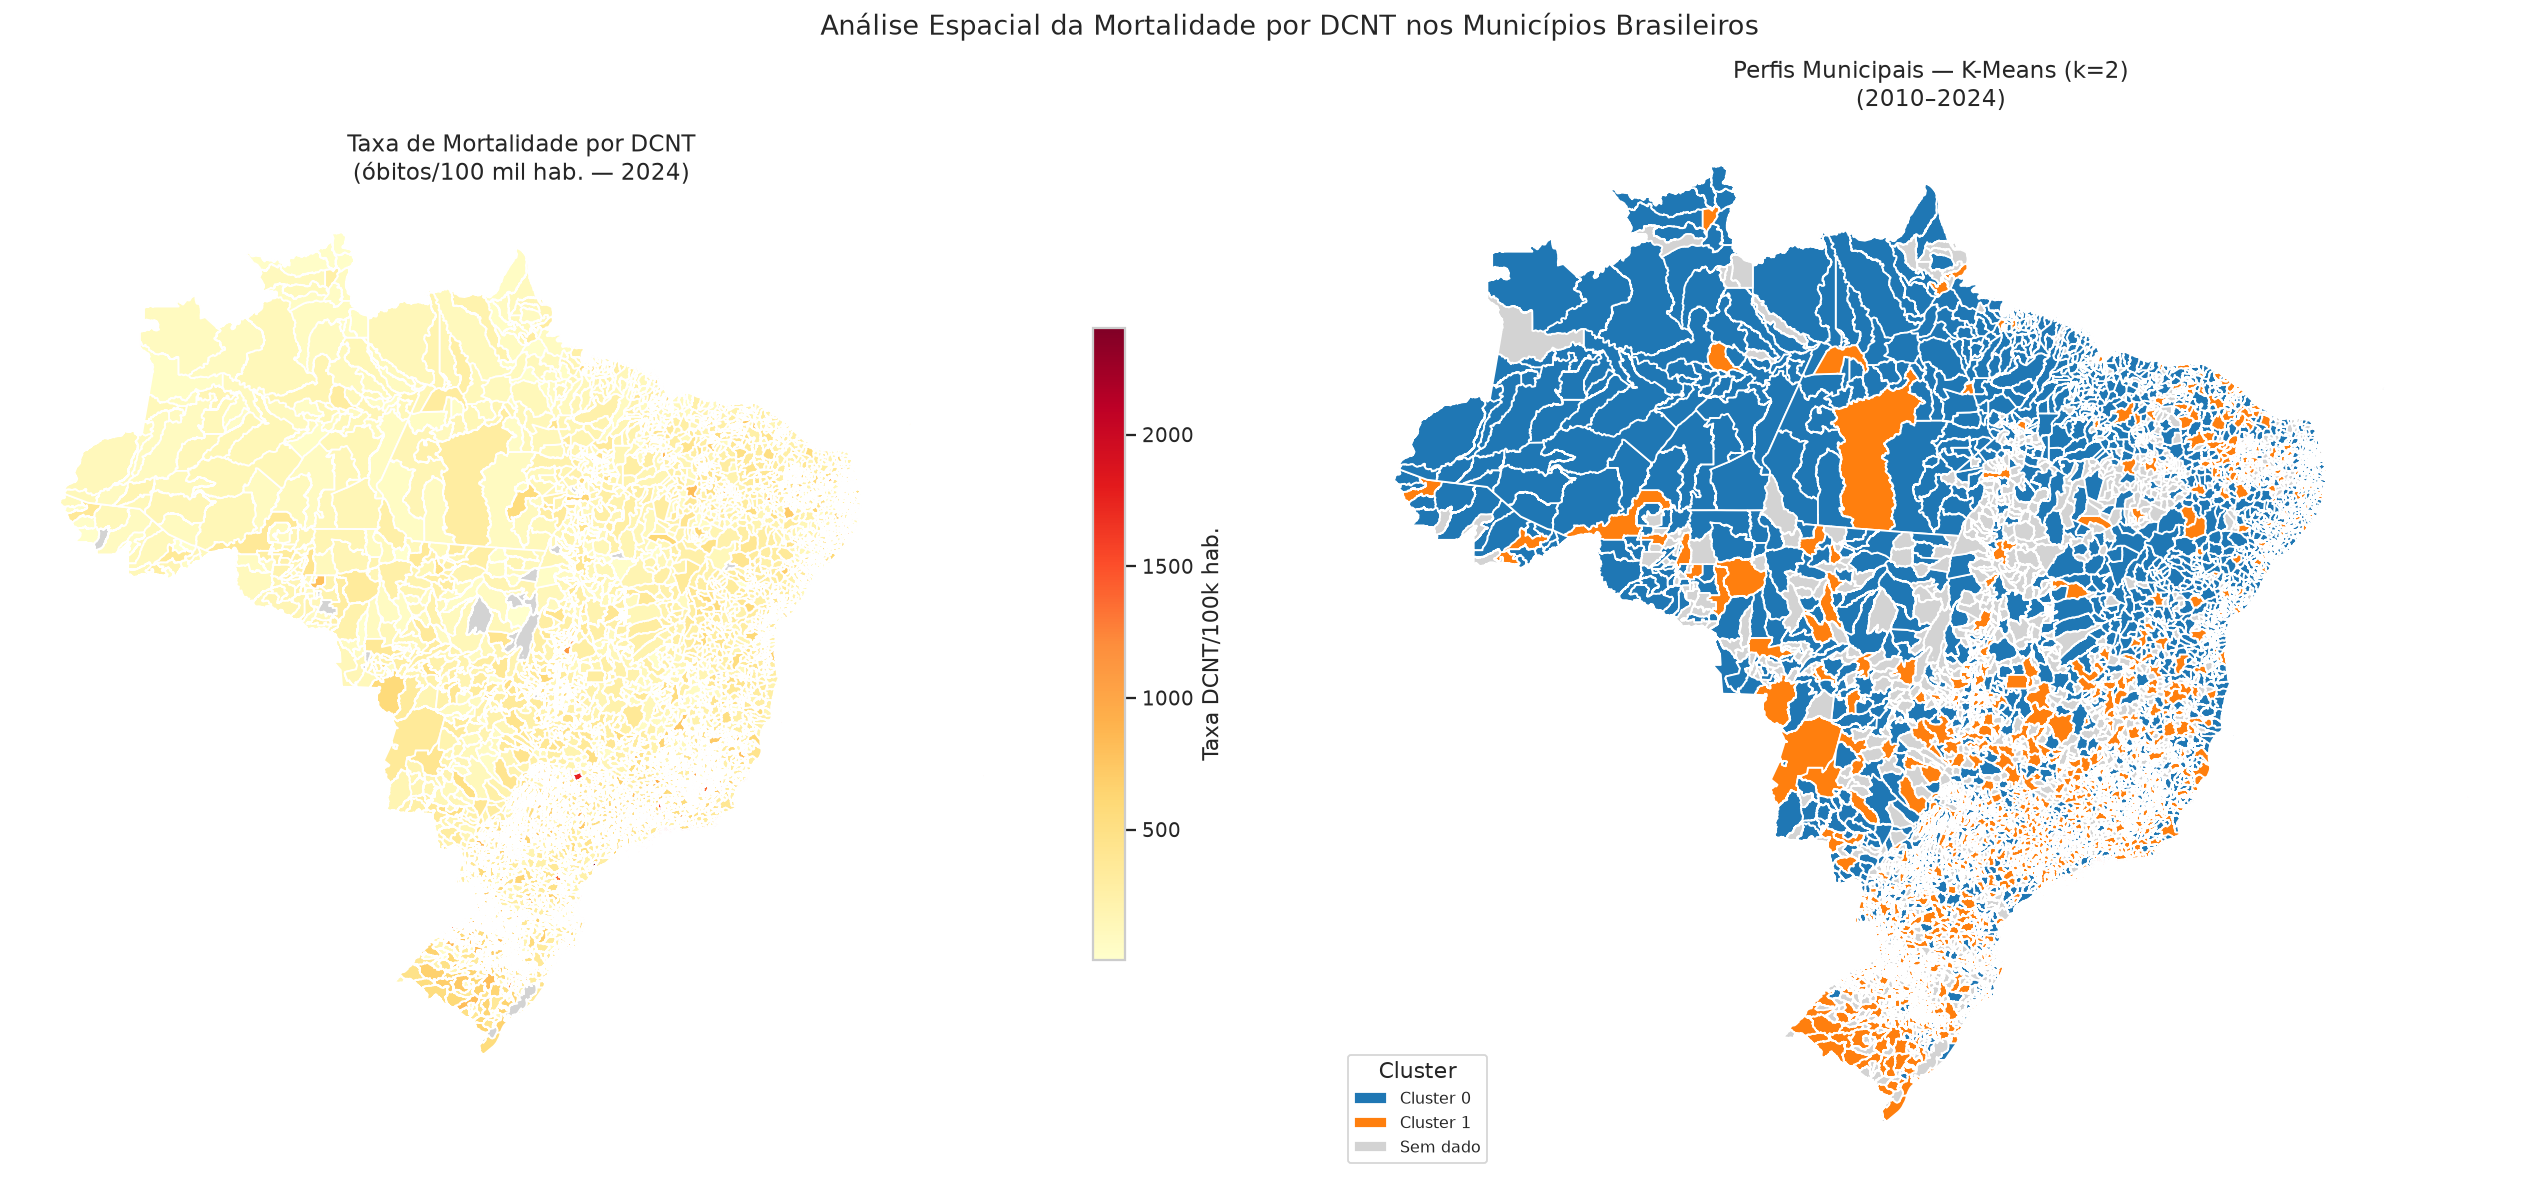

✅ Figura salva: dados/3-ouro/mapa_dcnt_clusters.png


In [14]:
# ── Semana 4 / 6.1: Mapa Coroplético ─────────────────────────────────────────
import geopandas as gpd
import zipfile, io, ssl
from urllib.request import urlopen
from matplotlib.patches import Patch
from matplotlib.colors import BoundaryNorm

SHAPE_DIR = Path('dados/shapefiles')
SHAPE_DIR.mkdir(parents=True, exist_ok=True)
SHAPE_SHP = SHAPE_DIR / 'BR_Municipios_2022.shp'

# ── Download do shapefile (se ainda não existir) ──────────────────────────────
if not SHAPE_SHP.exists():
    print('Baixando shapefile de municípios do IBGE 2022...')
    url = 'https://geoftp.ibge.gov.br/organizacao_do_territorio/malhas_territoriais/malhas_municipais/municipio_2022/Brasil/BR/BR_Municipios_2022.zip'
    ctx = ssl.create_default_context()
    ctx.check_hostname = False
    ctx.verify_mode = ssl.CERT_NONE
    with urlopen(url, context=ctx) as resp:
        data = resp.read()
    with zipfile.ZipFile(io.BytesIO(data)) as zf:
        zf.extractall(SHAPE_DIR)
    print('  Download concluído.')
else:
    print('  Shapefile já disponível, pulando download.')

geo = gpd.read_file(SHAPE_SHP)
print(f'  GeoDataFrame: {geo.shape}  CRS: {geo.crs}')

# ── Prepara chaves de join ────────────────────────────────────────────────────
# Shapefile IBGE usa CD_MUN (7 dígitos); features usa codigo_municipio (6 dígitos)
geo['cod6'] = geo['CD_MUN'].str[:6]

# Taxa média 2024 por município
taxa_2024 = taxa[taxa['exercicio'] == 2024][['codigo_municipio','taxa_dcnt_100k']].copy()

geo_merged = geo.merge(taxa_2024, left_on='cod6', right_on='codigo_municipio', how='left')
geo_merged = geo_merged.merge(
    features[['codigo_municipio','cluster']],
    left_on='cod6', right_on='codigo_municipio', how='left', suffixes=('','_feat'))

# Mantém cluster como float com NaN — o geopandas usa missing_kwds para pintar de cinza
geo_merged['cluster_plot'] = geo_merged['cluster'].astype('float')

n_sem_cluster = geo_merged['cluster_plot'].isna().sum()
print(f'  Municípios com cluster : {br(geo_merged["cluster_plot"].notna().sum())}')
print(f'  Municípios sem cluster : {br(n_sem_cluster)} (serão exibidos em cinza)')

# ── Paleta discreta para clusters ─────────────────────────────────────────────
CORES   = list(sns.color_palette('tab10', K_FINAL))  # mesma paleta da célula 5.3
CMAP_C  = plt.matplotlib.colors.ListedColormap(CORES)
bounds  = list(range(K_FINAL + 1))          # [0, 1, 2, ..., K_FINAL]
norm    = BoundaryNorm(bounds, CMAP_C.N)

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 9))

# Mapa 1: Taxa DCNT 2024
geo_merged.plot(
    column='taxa_dcnt_100k', ax=ax1,
    cmap='YlOrRd', legend=True,
    missing_kwds={'color': 'lightgrey', 'label': 'Sem dado'},
    legend_kwds={'label': 'Taxa DCNT/100k hab.', 'shrink': 0.6})
ax1.set_title('Taxa de Mortalidade por DCNT\n(óbitos/100 mil hab. — 2024)', fontsize=13)
ax1.axis('off')

# Mapa 2: Clusters (NaN → cinza via missing_kwds)
geo_merged.plot(
    column='cluster_plot', ax=ax2,
    cmap=CMAP_C, norm=norm, legend=False,
    missing_kwds={'color': 'lightgrey', 'label': 'Sem dado'})

# Legenda manual com cores corretas
legend_handles = [
    Patch(facecolor=CORES[c], label=f'Cluster {c}')
    for c in range(K_FINAL)
] + [Patch(facecolor='lightgrey', label='Sem dado')]
ax2.legend(handles=legend_handles, title='Cluster', loc='lower left', fontsize=9)
ax2.set_title(f'Perfis Municipais — K-Means (k={K_FINAL})\n(2010–2024)', fontsize=13)
ax2.axis('off')

plt.suptitle('Análise Espacial da Mortalidade por DCNT nos Municípios Brasileiros',
             fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig(OURO_DIR / 'mapa_dcnt_clusters.png', dpi=130, bbox_inches='tight')
plt.show()
print('✅ Figura salva: dados/3-ouro/mapa_dcnt_clusters.png')


### 📡 Célula 6.2 — Perfil dos Clusters (Gráfico de Barras Agrupadas)

Compara os clusters nas dimensões taxa média, tendência e composição DCNT.
Cada barra mostra o valor do cluster como **percentual do cluster com maior valor**
naquela dimensão — o líder sempre aparece em 100% e os demais mostram
quanto representam dele, sem que nenhuma barra fique invisível.

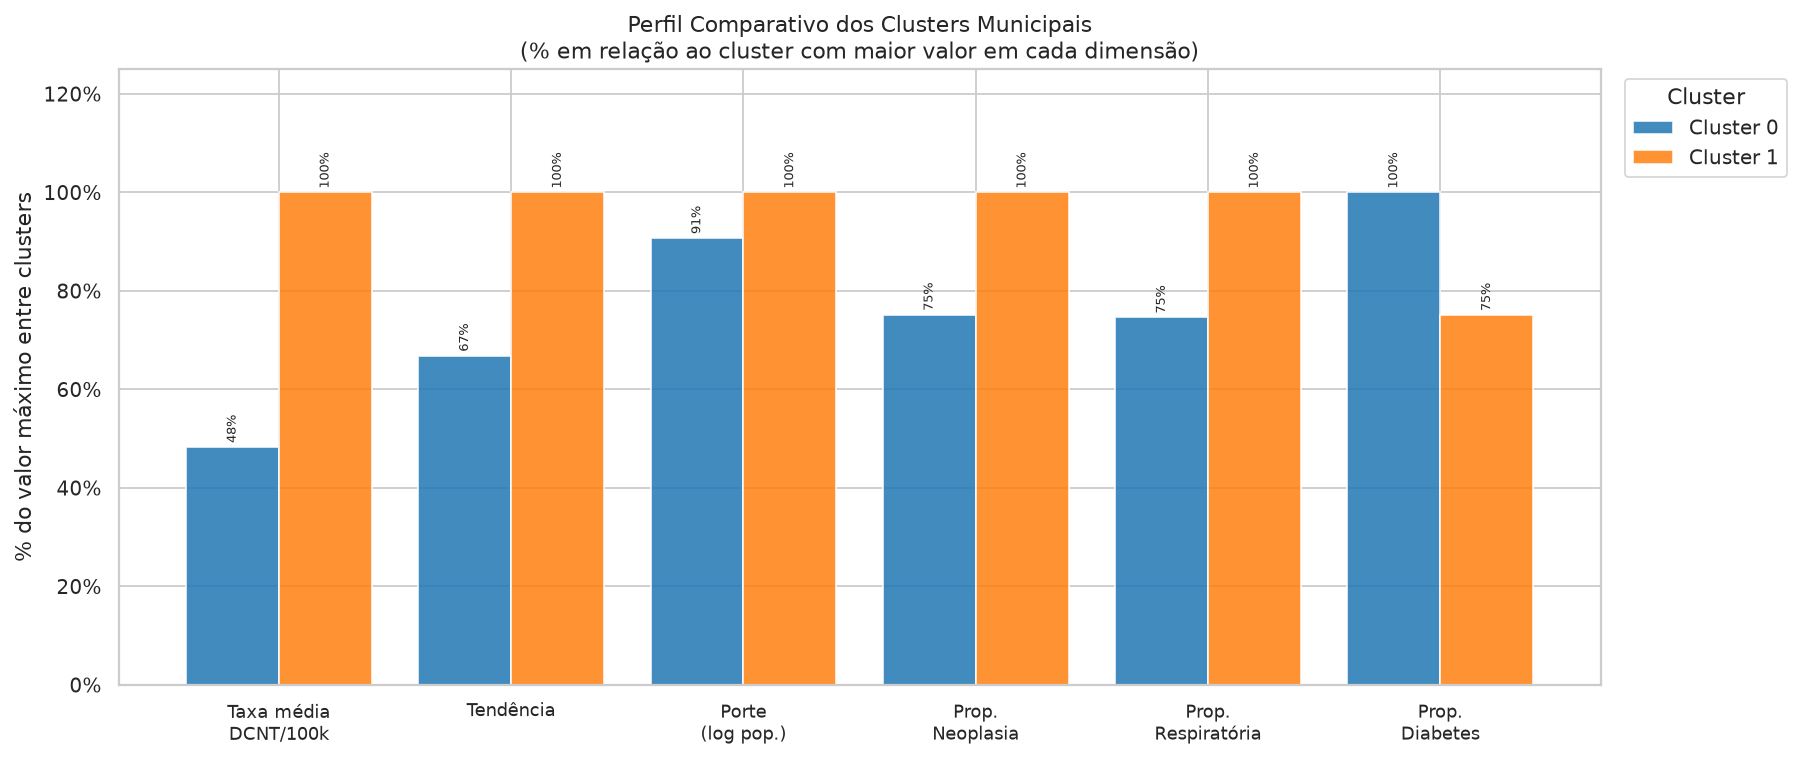

── Valores originais por Cluster ────────────────────────────────────────
         taxa_media  tendencia  log_pop_media  prop_neoplasia  prop_respiratoria  prop_diabetes
cluster                                                                                        
0        203,187000   4,313000       4,324000        0,206000           0,096000       0,123000
1        420,350000   6,450000       4,764000        0,274000           0,129000       0,092000

── % em relação ao máximo ───────────────────────────────────────────────
         taxa_media  tendencia  log_pop_media  prop_neoplasia  prop_respiratoria  prop_diabetes
cluster                                                                                        
0         48,300000  66,900000      90,800000       75,200000          74,600000     100,000000
1        100,000000 100,000000     100,000000      100,000000         100,000000      75,100000


In [15]:
# ── Semana 4 / 6.2: Perfil Comparativo dos Clusters ──────────────────────────
FEAT_LABELS = {
    'taxa_media'          : 'Taxa média\nDCNT/100k',
    'tendencia'           : 'Tendência',
    'log_pop_media'       : 'Porte\n(log pop.)',
    'prop_cardiovascular' : 'Prop.\nCardiovascular',
    'prop_neoplasia'      : 'Prop.\nNeoplasia',
    'prop_respiratoria'   : 'Prop.\nRespiratória',
    'prop_diabetes'       : 'Prop.\nDiabetes',
}

feat_display_cols = [c for c in FEAT_COLS if c in features.columns and c in FEAT_LABELS]
labels = [FEAT_LABELS[c] for c in feat_display_cols]

perfil_num = features.groupby('cluster')[feat_display_cols].mean()

# Percentual em relação ao maior valor de cada feature entre os clusters
# Garante que todas as barras são visíveis e o leitor vê quanto cada cluster
# representa do cluster "líder" naquela dimensão
perfil_pct = perfil_num.div(perfil_num.max()) * 100

x     = np.arange(len(labels))
width = 0.8 / K_FINAL

fig, ax = plt.subplots(figsize=(14, 6))
for i, row in perfil_pct.iterrows():
    offset = (i - (K_FINAL - 1) / 2) * width
    bars = ax.bar(x + offset, row[feat_display_cols].values, width,
                  label=f'Cluster {i}', color=PALETTE[i], alpha=0.85)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.8,
                f'{h:.0f}%', ha='center', va='bottom', fontsize=7, rotation=90)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('% do valor máximo entre clusters')
ax.set_ylim(0, 125)
ax.set_title('Perfil Comparativo dos Clusters Municipais\n(% em relação ao cluster com maior valor em cada dimensão)')
ax.legend(title='Cluster', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
plt.tight_layout()
plt.savefig(OURO_DIR / 'clustering_perfil.png', dpi=130, bbox_inches='tight')
plt.show()

print('── Valores originais por Cluster ────────────────────────────────────────')
print(perfil_num.round(3).to_string())
print()
print('── % em relação ao máximo ───────────────────────────────────────────────')
print(perfil_pct.round(1).to_string())
